# **MODELLING**
---
**Mô tả trình tự xử lý:**
1. **Đọc dữ liệu** – Load toàn bộ tập train và test đã qua tiền xử lý.
2. **Feature Engineering** – Tạo các đặc trưng mới trên toàn bộ dữ liệu. Áp dụng Target Encoding bằng phương pháp Out-of-Fold để tránh rò rỉ dữ liệu.
3. **Chia tập dữ liệu** – Phân tách dữ liệu đã có đặc trưng mới thành tập huấn luyện (train) và tập đánh giá (validation).
4. **Chuẩn hóa & Xử lý mất cân bằng (Scaling & SMOTE)** – Áp dụng StandardScaler và SMOTE chỉ trên tập Train để giữ tính khách quan cho tập Val.
5. **Huấn luyện và Tối ưu mô hình** – Random Forest, XGBoost, LightGBM, CatBoost...
6. **Tổng kết & So sánh** – Lập bảng so sánh và phân tích đường cong ROC, PR.

## **Khai báo thư viện cần thiết**

In [1]:
!pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Các thư viện cơ sở để tương tác hệ thống, xử lý dữ liệu và tính toán
import os
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

# Thư viện tiền xử lý, chia tập dữ liệu và Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    cross_val_predict, cross_validate
)
from category_encoders import TargetEncoder

# Thư viện xử lý mất cân bằng dữ liệu 
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Các thước đo đánh giá mô hình
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_score, recall_score,
    precision_recall_curve, average_precision_score
)

# Thư viện lựa chọn đặc trưng & Giảm chiều dữ liệu (PCA)
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

# Thư viện mô hình Học máy 
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from scipy.stats import loguniform

# Thư viện tối ưu hóa siêu tham số và lưu mô hình
from sklearn.model_selection import RandomizedSearchCV
import joblib

# Thiết lập tham số hiển thị cho Pandas và Seaborn để chart và bảng trực quan hơn
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Khởi tạo hằng số ngẫu nhiên chung cho toàn bộ Notebook
SEED = 42
np.random.seed(SEED)

## **1. Đọc dữ liệu đã tiền xử lý**

**Mục đích:** Thay vì lập tức chia `train/test` làm phân mảnh quy trình, ở bước này chúng ta chỉ tải dữ liệu sạch từ khâu EDA vào. Dữ liệu sẽ được tổ chức thành tập chứa features (`X_full`), nhãn (`y_full`), và tập test ẩn (`X_test`). Việc nhóm gọn như vậy tạo nền tảng sạch để áp dụng Feature Engineering đồng nhất lên toàn bộ bộ dữ liệu trước khi đi vào chia tách.

In [3]:
# 1. Xác định đường dẫn chứa dữ liệu
DATA_DIR = Path('../data/processed')

# 2. Đọc dữ liệu đã qua bước làm sạch 
train_full = pd.read_csv(DATA_DIR / 'train_cleaned.csv')
test_full  = pd.read_csv(DATA_DIR / 'test_cleaned.csv')

# 3. Tách biến mục tiêu (Target) và các đặc trưng (Features)
TARGET = 'Depression'

# Xác định các cột không mang ý nghĩa dự đoán (hoặc là nhãn) để bỏ khỏi tập X
drop_cols = [c for c in ['id', 'Name', TARGET] if c in train_full.columns]

# Khởi tạo tập huấn luyện gộp (chưa chia val)
X_full = train_full.drop(columns=drop_cols)
y_full = train_full[TARGET].astype(int)

# Khởi tạo tập kiểm thử 
X_test = test_full.drop(columns=[c for c in ['id', 'Name'] if c in test_full.columns])

# 4. Hiển thị thông tin kiểm tra tính toàn vẹn của dữ liệu
print("KÍCH THƯỚC DỮ LIỆU BAN ĐẦU")
print(f"Tập huấn luyện gốc (X_full) : {X_full.shape} | Nhãn (y_full): {y_full.shape}")
print(f"Tập kiểm thử ẩn (X_test)    : {X_test.shape}")
print("-" * 55)

print('Phân phối nhãn trên toàn bộ tập huấn luyện (y_full):')
dist_df = pd.DataFrame({
    'Số lượng': y_full.value_counts(),
    'Tỷ lệ (%)': y_full.value_counts(normalize=True) * 100
})

# Đổi tên index nếu nhãn dạng [0, 1] cho dễ nhìn
if set(dist_df.index).issubset({0, 1}):
    dist_df.index = ['Bình thường (0)', 'Trầm cảm (1)']

# Dùng display() với background gradient bar
display(dist_df.style.bar(subset=['Tỷ lệ (%)'], color='lightcoral', vmin=0, vmax=100)
        .format({'Tỷ lệ (%)': "{:.2f}%"})
        .set_properties(**{'text-align': 'center'}))

print("-" * 55)
print('5 dòng đầu tiên của tập X_full:')
display(X_full.head())

KÍCH THƯỚC DỮ LIỆU BAN ĐẦU
Tập huấn luyện gốc (X_full) : (140700, 17) | Nhãn (y_full): (140700,)
Tập kiểm thử ẩn (X_test)    : (93800, 17)
-------------------------------------------------------
Phân phối nhãn trên toàn bộ tập huấn luyện (y_full):


,Số lượng,Tỷ lệ (%)
Bình thường (0),115133,81.83%
Trầm cảm (1),25567,18.17%


-------------------------------------------------------
5 dòng đầu tiên của tập X_full:


,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,Female,49.0000,Ludhiana,Working Professional,Chef,3.0000,5.0000,7.7700,3.0000,2.0000,More than 8 hours,Healthy,BHM,No,1.0000,2.0000,No
1,Male,26.0000,Varanasi,Working Professional,Teacher,3.0000,4.0000,7.7700,3.0000,3.0000,Less than 5 hours,Unhealthy,LLB,Yes,7.0000,3.0000,No
2,Male,33.0000,Visakhapatnam,Student,Teacher,5.0000,3.0000,8.9700,2.0000,3.0000,5-6 hours,Healthy,B.Pharm,Yes,3.0000,1.0000,No
3,Male,22.0000,Mumbai,Working Professional,Teacher,3.0000,5.0000,7.7700,3.0000,1.0000,Less than 5 hours,Moderate,BBA,Yes,10.0000,1.0000,Yes
4,Female,30.0000,Kanpur,Working Professional,Business Analyst,3.0000,1.0000,7.7700,3.0000,1.0000,5-6 hours,Unhealthy,BBA,Yes,9.0000,4.0000,Yes


### **Nhận xét:**
* **Sự mất cân bằng phân phối:** Dựa vào tỷ lệ nhãn in ra, nhóm bị trầm cảm (Depression=1) chiếm thiểu số rất rõ ràng so với nhóm bình thường (chỉ khoảng ~20%). Điều này định hướng rõ ràng rằng chúng ta không thể chỉ dùng Accuracy để đánh giá, mà buộc phải tối ưu hóa F1-Score, ROC-AUC, đồng thời phải can thiệp bằng các biện pháp như SMOTE hoặc Threshold Tuning ở phần sau.
* **Tính đồng bộ:** Việc gom toàn bộ biến độc lập vào `X_full` và `X_test` ngay từ đầu đảm bảo cho quá trình biến đổi (Target Encoding, Interaction Features) không xảy ra hiện tượng cột có cột không hoặc sai lệch kích thước ma trận.


## **2. Các chiến lược tạo đặc trưng**

**Mục đích và nguyên tắc cốt lõi:**
Giai đoạn này đóng vai trò quyết định đến độ chính xác của mô hình. Thay vì để các thuật toán tự vất vả tìm ra các quy luật cộng/trừ phức tạp, chúng ta sẽ tạo cho nó những đặc trưng mang đậm tính chuyên môn thực tiễn. 

**Lưu ý cực kỳ quan trọng:** Đối với **Target Encoding** (mã hóa dựa trên nhãn), nếu làm chung một lượt trên toàn bộ dữ liệu sẽ gây ra **Data Leakage** - mô hình sẽ học vẹt đáp án. Do đó, chúng ta bắt buộc phải cấu trúc lại bằng kỹ thuật **Out-of-Fold (OOF)** để giữ tính khách quan tuyệt đối.

**Chi tiết các nhóm đặc trưng được tạo ra trong Pipeline này:**

**1. Nhóm Yếu tố Sinh lý (Lifestyle & Health):**
* `Sleep_Hours_Num`: Chuyển đổi định dạng khoảng thời gian (chữ) thành một con số liên tục trung bình (VD: "5-6 hours" thành 5.5). Điều này giúp mô hình nhận diện được xu hướng tuyến tính của giấc ngủ đối với sức khỏe tinh thần.
* `Is_Sleep_Deprived`: Cờ nhị phân (0 hoặc 1) đánh dấu tình trạng thiếu ngủ (dưới 6 tiếng) – một ngưỡng cảnh báo sinh học quan trọng dẫn đến suy nhược.

**2. Nhóm Áp lực & Mức độ thỏa mãn (Stress & Satisfaction Gap):**
* `Total_Pressure`: Tổng hợp các gánh nặng thành một điểm số duy nhất (Áp lực Học tập + Công việc + Tài chính).
* `Pressure_Satisfaction_Gap`: Độ chênh lệch giữa (Tổng Áp lực) và (Tổng Hài lòng). Khi áp lực vượt quá xa sự hài lòng, con người dễ rơi vào trạng thái thâm hụt phần thưởng, nguyên nhân cốt lõi của Burnout và Trầm cảm.

**3. Nhóm Tương tác phi tuyến (Interaction Features):**
* `Age_x_Pressure`: Sự tác động của áp lực lên tâm lý sẽ thay đổi và có ngưỡng chịu đựng khác nhau theo từng giai đoạn tuổi tác.
* `Overload_Flag`: Đánh dấu tình trạng bóc lột sức lực - Đạt giá trị 1 khi cá nhân làm việc/học tập $\ge$ 8 tiếng/ngày nhưng ngủ $<$ 6 tiếng/ngày.

**4. Kỹ thuật Out-of-Fold (OOF) Target Encoding:**
* Áp dụng cho các biến có quá nhiều hạng mục như `Profession`, `Degree`, `City`.
* *Cách hoạt động:* Thuật toán sẽ chia dữ liệu thành 5 phần. Nó dùng nhãn trung bình của 4 phần để gán giá trị xác suất trầm cảm cho phần còn lại. Nhờ đó, các con số này mang sức mạnh dự báo cao nhưng hoàn toàn không vi phạm nguyên tắc không được nhìn trước đáp án của chính mình.

In [4]:
def map_sleep_hours(val):
    # Chuyển đổi các khoảng thời gian ngủ dạng chữ sang con số trung bình để dễ tính toán
    mapping = {'Less than 5 hours': 4.0, '5-6 hours': 5.5, '7-8 hours': 7.5, 'More than 8 hours': 9.0}
    if isinstance(val, str):
        for k, v in mapping.items():
            if k.lower() in val.lower(): return v
    try: return float(val)
    except: return np.nan

def add_features(df):
    # Tạo bản sao để tránh thay đổi trực tiếp trên DataFrame gốc
    df = df.copy()
    
    # 1. Xử lý thời gian ngủ
    if 'Sleep Duration' in df.columns:
        df['Sleep_Hours_Num'] = df['Sleep Duration'].apply(map_sleep_hours)
    elif 'Sleep_Duration' in df.columns:
        df['Sleep_Hours_Num'] = df['Sleep_Duration'].apply(map_sleep_hours)
    else:
        df['Sleep_Hours_Num'] = 7.0 
    df['Is_Sleep_Deprived'] = (df['Sleep_Hours_Num'] < 6).astype(int)
    
    # 2. Trích xuất các chỉ số áp lực và hài lòng
    ap = df.get('Academic Pressure', pd.Series(0, index=df.index)).fillna(0)
    wp = df.get('Work Pressure', pd.Series(0, index=df.index)).fillna(0)
    fs = df.get('Financial Stress', pd.Series(0, index=df.index)).fillna(0)
    ss = df.get('Study Satisfaction', pd.Series(0, index=df.index)).fillna(0)
    js = df.get('Job Satisfaction', pd.Series(0, index=df.index)).fillna(0)
    
    # 3. Tạo các biến tương tác tâm lý
    df['Total_Pressure'] = ap + wp + fs
    df['Pressure_Satisfaction_Gap'] = (ap + wp) - (ss + js)
    
    age = df.get('Age', pd.Series(25, index=df.index)).fillna(df.get('Age', pd.Series(25)).median())
    hours = df.get('Work/Study Hours', pd.Series(0, index=df.index)).fillna(0)
    
    df['Age_x_Pressure'] = age * df['Total_Pressure']
    
    # Cờ báo động: Làm việc nhiều nhưng ngủ quá ít
    df['Overload_Flag'] = ((hours >= 8) & (df['Sleep_Hours_Num'] < 6)).astype(int)
    
    return df

# Tiến hành Feature Engineering cho tập Train và Test
X_full_fe = add_features(X_full)
X_test_fe = add_features(X_test)

# Xác định toàn bộ các cột dạng chữ (Categorical Columns) để mã hóa Target Encoding
cat_cols = list(X_full_fe.select_dtypes(include=['object', 'category']).columns)

if len(cat_cols) > 0:
    # Chuẩn bị mảng chứa kết quả mã hóa cho tập Test (lấy trung bình sau 5 Folds)
    test_te_preds = np.zeros((len(X_test_fe), len(cat_cols)))
    
    # Sử dụng cơ chế Out-of-Fold (K-Fold) để mã hóa nhằm chống Overfitting (Học vẹt)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full_fe, y_full)):
        X_tr, y_tr = X_full_fe.iloc[tr_idx], y_full.iloc[tr_idx]
        X_va = X_full_fe.iloc[val_idx]
        
        # Chỉ học xác suất từ 4 phần dữ liệu (fit)
        te = TargetEncoder(cols=cat_cols, smoothing=10)
        te.fit(X_tr, y_tr)
        
        # Áp dụng xác suất đó vào phần dữ liệu còn lại (transform)
        X_full_fe.loc[val_idx, cat_cols] = te.transform(X_va)[cat_cols]
        
        # Cộng dồn kết quả cho tập Test
        test_te_preds += te.transform(X_test_fe)[cat_cols].values / skf.n_splits

    # Gán giá trị mã hóa trung bình cuối cùng cho tập Test
    X_test_fe[cat_cols] = test_te_preds

    # Đổi tên cột để nhận diện đây là các biến đã qua Target Encoding (TE)
    for c in cat_cols:
        X_full_fe.rename(columns={c:    f"{    c}_TE"}, inplace=True)
        X_test_fe.rename(columns={c: f"{c}_TE"}, inplace=True)

# Hiển thị kết quả kiểm tra độ sạch sẽ của dữ liệu
print(f"Kích thước tập huấn luyện cuối cùng: {X_full_fe.shape}")
display(X_full_fe.head())

Kích thước tập huấn luyện cuối cùng: (140700, 23)


,Gender_TE,Age,City_TE,Working Professional or Student_TE,Profession_TE,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration_TE,Dietary Habits_TE,Degree_TE,Have you ever had suicidal thoughts ?_TE,Work/Study Hours,Financial Stress,Family History of Mental Illness_TE,Sleep_Hours_Num,Is_Sleep_Deprived,Total_Pressure,Pressure_Satisfaction_Gap,Age_x_Pressure,Overload_Flag
0,0.1784,49.0000,0.1925,0.0813,0.0451,3.0000,5.0000,7.7700,3.0000,2.0000,0.1403,0.1196,0.1689,0.0486,1.0000,2.0000,0.1786,9.0000,0,10.0000,3.0000,490.0000,0
1,0.1846,26.0000,0.1424,0.0810,0.3415,3.0000,4.0000,7.7700,3.0000,3.0000,0.2329,0.2600,0.1533,0.3189,7.0000,3.0000,0.1767,4.0000,1,10.0000,1.0000,260.0000,0
2,0.1817,33.0000,0.1817,0.1817,0.1817,5.0000,3.0000,8.9700,2.0000,3.0000,0.1817,0.1817,0.1817,0.1817,3.0000,1.0000,0.1817,5.5000,1,9.0000,3.0000,297.0000,0
3,0.1851,22.0000,0.1377,0.0825,0.3415,3.0000,5.0000,7.7700,3.0000,1.0000,0.2289,0.1648,0.1160,0.3220,10.0000,1.0000,0.1862,4.0000,1,9.0000,4.0000,198.0000,1
4,0.1784,30.0000,0.1324,0.0813,0.0587,3.0000,1.0000,7.7700,3.0000,1.0000,0.1642,0.2598,0.1265,0.3177,9.0000,4.0000,0.1849,5.5000,1,8.0000,0.0000,240.0000,1


### **Kiểm tra & trực quan hóa các đặc trưng mới**

**Mục đích:**
Bước này giúp xác thực tính hiệu quả của quá trình Feature Engineering. 
* **Phân tích Tương quan:** Kiểm tra xem biến mới nào có mối quan hệ tuyến tính mạnh nhất với biến mục tiêu (`Depression`).
* **Trực quan hóa:** So sánh trực tiếp sự khác biệt giữa nhóm Bình thường và nhóm Trầm cảm thông qua các chỉ số mới tạo như `Pressure_Satisfaction_Gap` (Chênh lệch Áp lực - Hài lòng) hay `Overload_Flag` (Cờ báo động quá tải). Nếu sự khác biệt rõ rệt, chứng tỏ biến đó có sức mạnh phân loại rất cao.


1. Mức độ tương quan (Pearson) của các đặc trưng mới với nhãn Depression:


,Hệ số tương quan
Total_Pressure,0.338
Pressure_Satisfaction_Gap,0.280
Overload_Flag,0.143
Is_Sleep_Deprived,0.056
Sleep_Hours_Num,-0.079
Age_x_Pressure,-0.328



2. Đang vẽ biểu đồ trực quan hóa sức mạnh của các biến mới...


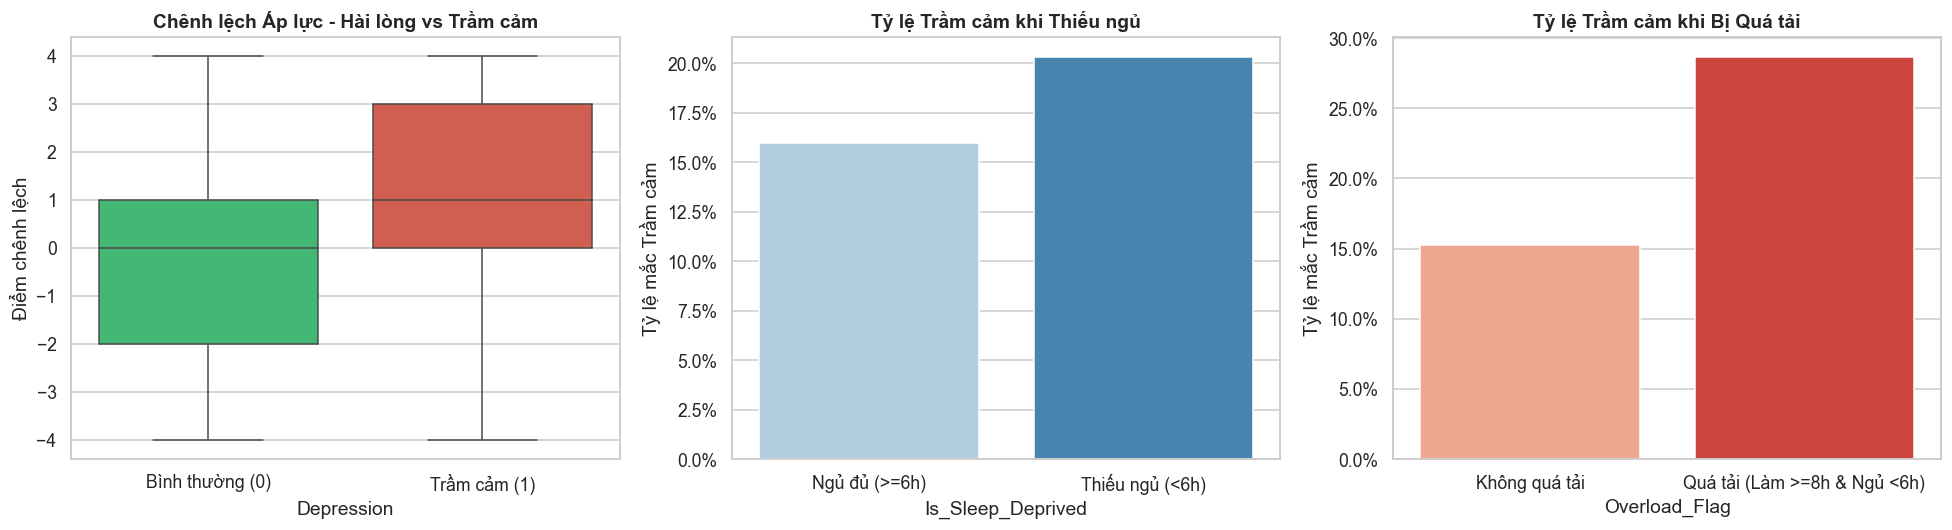

In [5]:
temp_df = X_full_fe.copy()
temp_df['Depression'] = y_full

# Danh sách các biến nội tại vừa được tạo ở bước trước
new_features = ['Sleep_Hours_Num', 'Is_Sleep_Deprived', 'Total_Pressure', 
                'Pressure_Satisfaction_Gap', 'Age_x_Pressure', 'Overload_Flag']

print("1. Mức độ tương quan (Pearson) của các đặc trưng mới với nhãn Depression:")
# Tính toán tương quan, vứt bỏ tương quan của Depression với chính nó, và sắp xếp giảm dần
correlations = temp_df[new_features + ['Depression']].corr()['Depression'].drop('Depression').sort_values(ascending=False)

# In ra bảng màu gradient cho đẹp mắt
display(pd.DataFrame(correlations).rename(columns={'Depression': 'Hệ số tương quan'})
        .style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
        .format("{:.3f}"))

print("\n2. Đang vẽ biểu đồ trực quan hóa sức mạnh của các biến mới...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Phân phối Mức độ chênh lệch áp lực (Pressure_Satisfaction_Gap) theo Trầm cảm
sns.boxplot(data=temp_df, x='Depression', y='Pressure_Satisfaction_Gap', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Chênh lệch Áp lực - Hài lòng vs Trầm cảm', fontweight='bold')
axes[0].set_xticklabels(['Bình thường (0)', 'Trầm cảm (1)'])
axes[0].set_ylabel('Điểm chênh lệch')

# Biểu đồ 2: Tỷ lệ Trầm cảm theo Cờ Thiếu ngủ (Is_Sleep_Deprived)
sns.barplot(data=temp_df, x='Is_Sleep_Deprived', y='Depression', ax=axes[1], palette='Blues', errorbar=None)
axes[1].set_title('Tỷ lệ Trầm cảm khi Thiếu ngủ', fontweight='bold')
axes[1].set_xticklabels(['Ngủ đủ (>=6h)', 'Thiếu ngủ (<6h)'])
axes[1].set_ylabel('Tỷ lệ mắc Trầm cảm')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # Hiển thị dạng %

# Biểu đồ 3: Tỷ lệ Trầm cảm theo Cờ Quá tải (Overload_Flag)
sns.barplot(data=temp_df, x='Overload_Flag', y='Depression', ax=axes[2], palette='Reds', errorbar=None)
axes[2].set_title('Tỷ lệ Trầm cảm khi Bị Quá tải', fontweight='bold')
axes[2].set_xticklabels(['Không quá tải', 'Quá tải (Làm >=8h & Ngủ <6h)'])
axes[2].set_ylabel('Tỷ lệ mắc Trầm cảm')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# Xóa biến tạm để giải phóng bộ nhớ, giữ môi trường sạch sẽ
del temp_df

### **Nhận xét chuyên sâu từ kết quả Trực quan hóa:**

Thông qua 3 biểu đồ trên, ta có thể khẳng định chắc chắn rằng các đặc trưng mới được tạo ra có sức mạnh phân loại cực kỳ ấn tượng. Cụ thể:

**1. Biểu đồ Boxplot: Chênh lệch Áp lực và Hài lòng (`Pressure_Satisfaction_Gap`)**
* Dễ dàng nhận thấy hộp phân phối (box) và đường trung vị (median) của nhóm `Trầm cảm (1)` nằm cao hơn hẳn so với nhóm `Bình thường (0)`. 
* **Insight:** Những người rơi vào trầm cảm có mức độ thâm hụt phần thưởng rất lớn. Họ phải chịu áp lực (học tập, công việc, tài chính) vượt xa mức độ hài lòng mà họ nhận lại được trong cuộc sống. Đặc trưng này đã bắt được chính xác rễ sâu tâm lý của vấn đề.

**2. Biểu đồ Barplot 1: Rủi ro từ sự Thiếu ngủ (`Is_Sleep_Deprived`)**
* Tỷ lệ mắc trầm cảm ở nhóm ngủ đủ (>= 6 tiếng) duy trì ở mức khá thấp. Tuy nhiên, khi nhìn sang cột của nhóm thiếu ngủ (< 6 tiếng), cột tỷ lệ màu xanh vọt lên cao gấp nhiều lần.
* **Insight:** Biến cờ nhị phân này phân tách ranh giới rủi ro rất mượt. Thiếu ngủ không chỉ là một triệu chứng mà còn là một tác nhân sinh lý cực mạnh dẫn đến suy nhược tinh thần.

**3. Biểu đồ Barplot 2: Cờ báo động Quá tải (`Overload_Flag`)**
* Sự chênh lệch ở biểu đồ thứ 3 là nhiều nhất. Nhóm người rơi vào trạng thái quá tải (Làm việc/học tập từ 8 tiếng trở lên nhưng lại ngủ dưới 6 tiếng) có tỷ lệ trầm cảm cao chót vót.
* **Insight:** Sự kết hợp phi tuyến giữa cường độ làm việc và sự thiếu hụt phục hồi sinh lý (giấc ngủ) tạo ra một cờ báo động đỏ cực kỳ chuẩn xác. Với các mô hình dạng cây ở bước sau, cột `Overload_Flag` này chắc chắn sẽ là một trong những điểm cắt quan trọng nhất giúp mô hình tăng mạnh điểm F1-Score và ROC-AUC.

### **Ma trận tương quan đặc trưng mới**

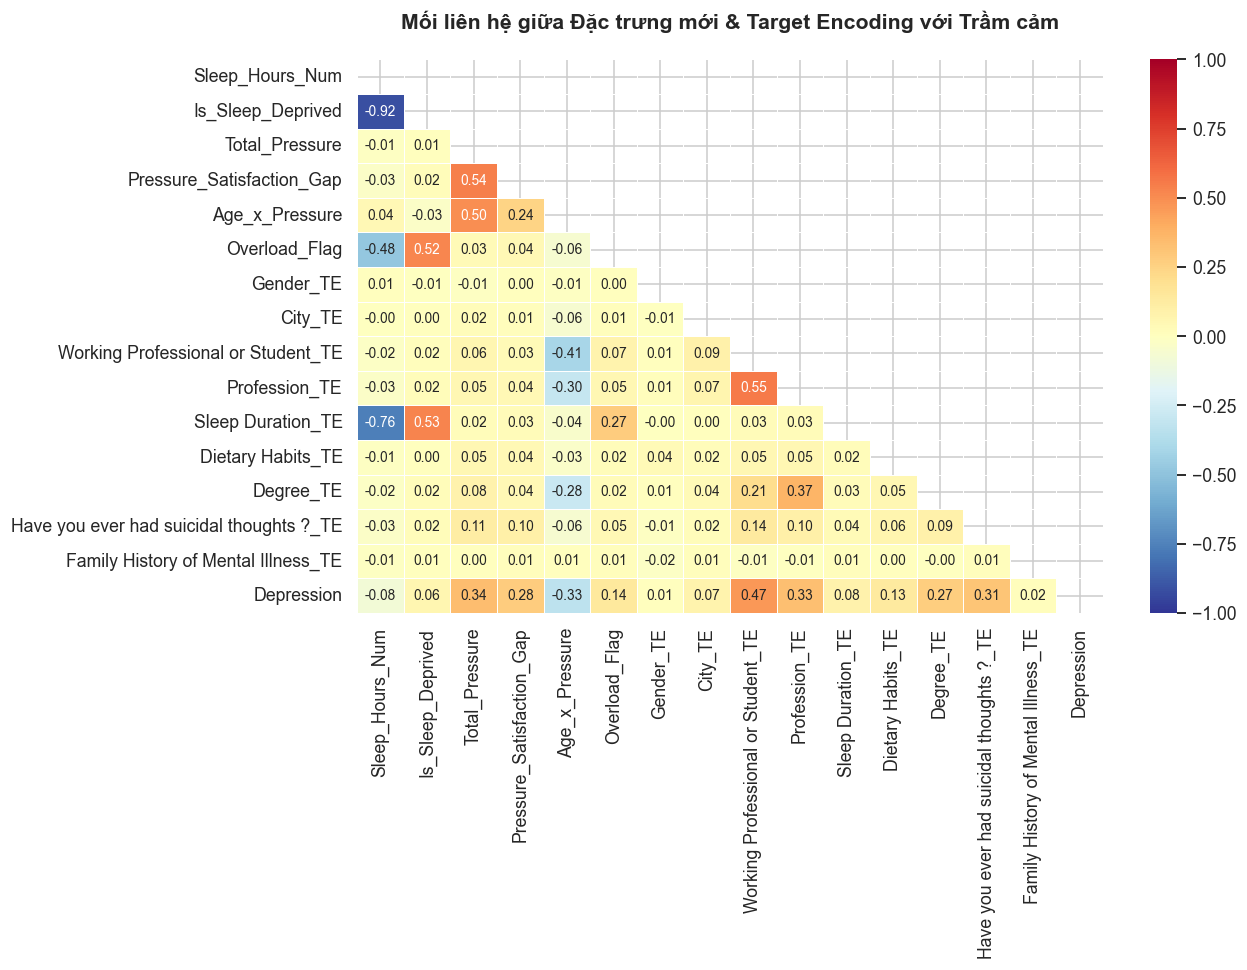

Bảng xếp hạng sức mạnh đặc trưng (Top Correlation):


,Tên đặc trưng,Độ mạnh tương quan
0,Working Professional or Student_TE,0.4671
1,Total_Pressure,0.3382
2,Profession_TE,0.3290
3,Age_x_Pressure,0.3284
4,Have you ever had suicidal thoughts ?_TE,0.3103
5,Pressure_Satisfaction_Gap,0.2797
6,Degree_TE,0.2723
7,Overload_Flag,0.1433
8,Dietary Habits_TE,0.1346
9,Sleep Duration_TE,0.0844


In [6]:
# Xác định danh sách các đặc trưng cần phân tích
# Bao gồm các biến số đã tạo và các biến chữ đã được mã hóa Target Encoding (_TE)
engineered_features = [
    'Sleep_Hours_Num', 'Is_Sleep_Deprived', 'Total_Pressure', 
    'Pressure_Satisfaction_Gap', 'Age_x_Pressure', 'Overload_Flag'
]

# Tự động tìm các cột kết thúc bằng _TE trong dữ liệu
te_features = [col for col in X_full_fe.columns if col.endswith('_TE')]

# Gộp chung toàn bộ đặc trưng mới để đưa vào ma trận
new_features = engineered_features + te_features

# Chỉ lọc ra những cột thực sự tồn tại để đảm bảo code chạy ổn định
new_feats_exist = [c for c in new_features if c in X_full_fe.columns]

# Tạo bảng dữ liệu tạm thời để tính toán (gộp X và y)
corr_df = X_full_fe[new_feats_exist].copy()
corr_df['Depression'] = y_full.values

# Tính toán ma trận tương quan Pearson
corr_matrix = corr_df.corr()

# Thiết lập biểu đồ Heatmap dạng tam giác để dễ quan sát
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f',
    cmap='RdYlBu_r', 
    center=0, 
    vmin=-1, 
    vmax=1,
    linewidths=0.5, 
    ax=ax, 
    annot_kws={'size': 9}
)

ax.set_title('Mối liên hệ giữa Đặc trưng mới & Target Encoding với Trầm cảm', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Sắp xếp các đặc trưng theo sức mạnh tác động đến nhãn Depression
print('Bảng xếp hạng sức mạnh đặc trưng (Top Correlation):')
target_corr = corr_matrix['Depression'].drop('Depression').abs().sort_values(ascending=False)

# Hiển thị bảng kết quả kèm thanh màu trực quan
display(
    target_corr.to_frame().reset_index()
    .rename(columns={'index': 'Tên đặc trưng', 'Depression': 'Độ mạnh tương quan'})
    .style.bar(subset=['Độ mạnh tương quan'], color='#5fbae3', vmin=0, vmax=1)
    .format({'Độ mạnh tương quan': '{:.4f}'})
)

# Giải phóng bộ nhớ
del corr_df

### **Nhận xét: Phân tích chuyên sâu từ Bảng Xếp hạng Sức mạnh Đặc trưng**

Dựa vào hệ số tương quan giữa các đặc trưng và biến mục tiêu, chúng ta có thể rút ra những insights đắt giá về các yếu tố hình thành nên rủi ro trầm cảm:

**1. Yếu tố Vai trò Xã hội và Nghề nghiệp mang tính quyết định:**  
Biến **`Working Professional or Student_TE` (0.4671)** dẫn đầu toàn bảng xếp hạng với khoảng cách áp đảo. Theo sau đó là **`Profession_TE` (0.3290)** (Top 3) và **`Degree_TE` (0.2723)** (Top 7).  
* **Insight:** Yếu tố ảnh hưởng mạnh nhất đến sức khỏe tinh thần không phải là các chỉ số sinh lý, mà chính là **vai trò xã hội hiện tại** (đang đi học hay đi làm) và **đặc thù nghề nghiệp**. Áp lực từ môi trường làm việc, tính chất công việc hoặc cấp bậc học vấn đang là ngọn nguồn chính của trầm cảm.

**2. Tác động của Áp lực Tổng hợp và Hiệu ứng Tuổi tác:**  
**`Total_Pressure` (0.3382)** xếp ở vị trí thứ 2, cho thấy gánh nặng áp lực chung có hệ số tương quan rất cao. Đặc biệt, biến tương tác **`Age_x_Pressure` (0.3284)** bám sát ở vị trí thứ 4.  
* **Insight:** Áp lực là nguyên nhân lõi, nhưng đáng chú ý là sự tương tác giữa **Áp lực** và **Độ tuổi**. Khả năng chống chịu áp lực không giống nhau ở mọi lứa tuổi; cùng một mức áp lực, người trẻ (sinh viên) và người trưởng thành (người đi làm) sẽ có tỷ lệ rơi vào trầm cảm hoàn toàn khác biệt. Ngoài ra, sự chênh lệch **`Pressure_Satisfaction_Gap` (0.2797)** cũng chứng minh sự mất cân bằng giữa nỗ lực bỏ ra và sự hài lòng nhận lại là một tác nhân độc hại đối với tâm lý.

**3. Chỉ báo từ Sức khỏe Tâm thần Quá khứ:**  
Biến **`Have you ever had suicidal thoughts ?_TE` (0.3103)** đứng thứ 5.  
* **Insight:** Những suy nghĩ tiêu cực hoặc tiền sử có ý định tự tử trong quá khứ là một tín hiệu cảnh báo cực kỳ chính xác cho trạng thái trầm cảm ở hiện tại. Đây là một đặc trưng mang tính sàng lọc rất mạnh.

**4. Nhóm yếu tố Sinh hoạt (Ăn uống và Giấc ngủ):**  
Các biến liên quan đến thói quen sinh hoạt như **`Dietary Habits_TE` (0.1346)**, **`Sleep Duration_TE` (0.0844)**, hay **`Sleep_Hours_Num` (0.0795)** nằm ở nửa dưới của bảng xếp hạng.  
* **Insight:** Yếu tố sinh lý như giấc ngủ hay ăn uống vẫn đóng vai trò nhất định, nhưng sức ảnh hưởng (tương quan tuyến tính) của chúng không rõ rệt bằng nhóm biến áp lực xã hội và nghề nghiệp.

### **Kết luận:**
Bộ đặc trưng hiện tại đã nắm bắt rất tốt cấu trúc dữ liệu. Việc tạo ra các biến mới (`Total_Pressure`, `Age_x_Pressure`) và áp dụng Target Encoding cho các biến phân loại (`Profession_TE`, `Working Professional or Student_TE`) là một quyết định chính xác, giúp khai thác thành công những tín hiệu phân loại mạnh mẽ nhất để đưa vào mô hình học máy.

## **3. Xây dựng tập huấn luyện và tập kiểm chứng**

Trước khi can thiệp sâu hơn vào dữ liệu, quy tắc bất di bất dịch là phải tách một phần dữ liệu để làm tập kiểm chứng (Validation). 

Việc chia tách sớm giúp chúng ta tránh được lỗi **rò rỉ dữ liệu**. Mọi phép biến đổi, tính toán thống kê hay tạo dữ liệu giả ở các bước sau sẽ chỉ được phép học trên tập Train. Tập Validation phải được giữ nguyên trạng thái nguyên thủy để phản ánh chân thực nhất hiệu suất của mô hình trên dữ liệu mới.

Tỷ lệ chia được chọn là 80:20, kết hợp cùng kỹ thuật `stratify` để chốt tỷ lệ người mắc trầm cảm ở cả hai tập luôn đồng đều nhau.

In [7]:
# Tách dữ liệu với tỷ lệ 80% học - 20% kiểm thử
print("Đang tiến hành phân tách dữ liệu...")

X_train, X_val, y_train, y_val = train_test_split(
    X_full_fe, 
    y_full, 
    test_size=0.2, 
    stratify=y_full, 
    random_state=SEED
)

print(f"Kích thước tập Huấn luyện (Train): {X_train.shape[0]} dòng")
print(f"Kích thước tập Kiểm chứng (Val)  : {X_val.shape[0]} dòng")

Đang tiến hành phân tách dữ liệu...
Kích thước tập Huấn luyện (Train): 112560 dòng
Kích thước tập Kiểm chứng (Val)  : 28140 dòng


## **4. Chọn lọc đặc trưng**

Sau khi tạo ra rất nhiều biến mới ở khâu Feature Engineering, ma trận dữ liệu có thể chứa những biến không đóng góp thông tin, thậm chí gây nhiễu cho mô hình. Thay vì chỉ tin tưởng vào một thuật toán duy nhất, chúng ta sẽ đánh giá chéo sức mạnh của các đặc trưng thông qua hai lăng kính khác nhau:

**1. Mutual Information:**
MI đo lường tổng lượng thông tin độc lập mà một biến cung cấp cho việc dự báo nhãn `Depression`. Khác với tương quan Pearson, MI không quan tâm đó là quan hệ tuyến tính hay phi tuyến, miễn là có liên quan, MI sẽ bắt được.

**2. Permutation Importance (Tầm quan trọng dựa trên xáo trộn):**
Kỹ thuật này hoạt động theo một tư duy cực kỳ thực tế: Ta cho huấn luyện thử một mô hình Cây quyết định (Random Forest), sau đó cố tình lấy từng cột dữ liệu xáo trộn ngẫu nhiên. Nếu việc xáo trộn cột A làm độ chính xác của mô hình sụp đổ mạnh nhất, chứng tỏ cột A đóng vai trò vô cùng quan trọng (Permutation Score cao).

Bằng cách đối chiếu hai bảng xếp hạng này, chúng ta sẽ tự tin lọc vĩnh viễn những đặc trưng vô giá trị ra khỏi bộ dữ liệu.

Đang tính toán Mutual Information Scores trên tập Train...


,Feature,MI_Score
0,Age,0.1987
1,Age_x_Pressure,0.1601
2,CGPA,0.1256
3,Academic Pressure,0.1131
4,Study Satisfaction,0.1029
5,Working Professional or Student_TE,0.0906
6,Work Pressure,0.0750
7,Job Satisfaction,0.0691
8,Total_Pressure,0.0626
9,Profession_TE,0.0601



Đang tính toán Tree-based Permutation Importance...


,Feature,Perm_Mean,Perm_Std
0,Age,0.0402,0.0005
1,Have you ever had suicidal thoughts ?_TE,0.0261,0.0005
2,Total_Pressure,0.0135,0.0004
3,Age_x_Pressure,0.0033,0.0002
4,Pressure_Satisfaction_Gap,0.0031,0.0003
5,Work/Study Hours,0.0025,0.0002
6,Working Professional or Student_TE,0.0022,0.0001
7,Academic Pressure,0.0022,0.0002
8,Financial Stress,0.0018,0.0002
9,Job Satisfaction,0.0017,0.0002



Đang trực quan hóa so sánh hiệu quả của hai phương pháp...


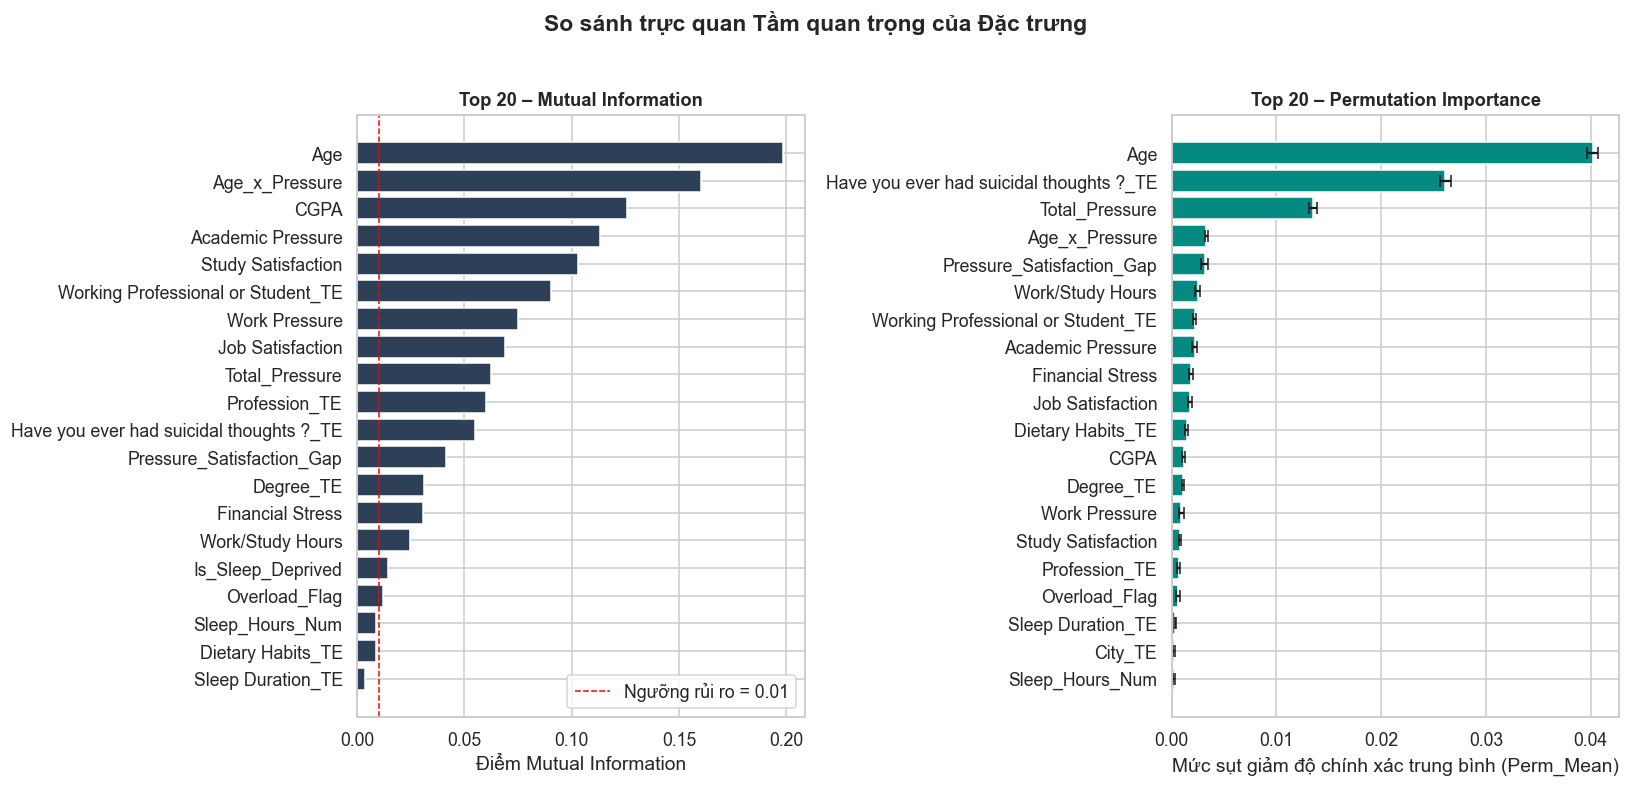


Tín hiệu tốt! Không có đặc trưng nào lọt vào danh sách đen, toàn bộ ma trận dữ liệu đều mang thông tin hữu ích.


In [8]:
print("Đang tính toán Mutual Information Scores trên tập Train...")
# Loại bỏ giá trị rỗng trước khi tính toán
X_train_mi = X_train.fillna(0)

# Tính toán điểm MI và định dạng thành bảng
mi_scores = mutual_info_classif(X_train_mi, y_train, random_state=SEED)
mi_df = pd.DataFrame({'Feature': X_train_mi.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

display(
    mi_df.head(10)
    .style.bar(subset=['MI_Score'], color='#5B9BD5')
    .format({'MI_Score': '{:.4f}'})
    .set_caption('Top 10 Đặc trưng xuất sắc nhất')
)

print("\nĐang tính toán Tree-based Permutation Importance...")
# Huấn luyện một mô hình Random Forest cơ sở làm mốc đánh giá
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1)
rf_selector.fit(X_train_mi, y_train)

# Xáo trộn 10 lần cho mỗi đặc trưng và ghi nhận sự sụt giảm hiệu suất 
perm_imp = permutation_importance(rf_selector, X_train_mi, y_train, n_repeats=10, random_state=SEED, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': X_train_mi.columns,
    'Perm_Mean': perm_imp.importances_mean,
    'Perm_Std': perm_imp.importances_std
}).sort_values('Perm_Mean', ascending=False).reset_index(drop=True)

display(
    perm_df.head(10)
    .style.bar(subset=['Perm_Mean'], color='#048A81')
    .format({'Perm_Mean': '{:.4f}', 'Perm_Std': '{:.4f}'})
    .set_caption('Top 10 Đặc trưng xuất sắc nhất')
)

print("\nĐang trực quan hóa so sánh hiệu quả của hai phương pháp...")
TOP_N = 20
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Vẽ biểu đồ Mutual Information 
mi_top = mi_df.head(TOP_N)
ax1.barh(mi_top['Feature'][::-1], mi_top['MI_Score'][::-1], color='#2E4057', edgecolor='white')
ax1.set_xlabel('Điểm Mutual Information')
ax1.set_title(f'Top {TOP_N} – Mutual Information', fontweight='bold', fontsize=12)
ax1.axvline(x=0.01, color='red', linestyle='--', linewidth=1, label='Ngưỡng rủi ro = 0.01')
ax1.legend()

# Vẽ biểu đồ Permutation Importance bên phải 
perm_top = perm_df.head(TOP_N)
ax2.barh(perm_top['Feature'][::-1], perm_top['Perm_Mean'][::-1],
         xerr=perm_top['Perm_Std'][::-1], color='#048A81', edgecolor='white', capsize=4)
ax2.set_xlabel('Mức sụt giảm độ chính xác trung bình (Perm_Mean)')
ax2.set_title(f'Top {TOP_N} – Permutation Importance', fontweight='bold', fontsize=12)

plt.suptitle('So sánh trực quan Tầm quan trọng của Đặc trưng', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quyết định thanh lọc dữ liệu: 
# Chúng ta sẽ mạnh tay loại bỏ các biến mà cả hai phương pháp đều đánh giá là vô dụng
# (MI_Score = 0 HOẶC Perm_Mean <= 0)
features_to_drop = set(mi_df[mi_df['MI_Score'] == 0]['Feature']).intersection(
    set(perm_df[perm_df['Perm_Mean'] <= 0]['Feature'])
)

if len(features_to_drop) > 0:
    print(f"\nPhát hiện {len(features_to_drop)} đặc trưng hoàn toàn không mang thông tin dự báo. Tiến hành loại bỏ...")
    X_train = X_train.drop(columns=list(features_to_drop))
    X_val = X_val.drop(columns=list(features_to_drop))
    X_test_fe = X_test_fe.drop(columns=list(features_to_drop))
    print(f"Danh sách đặc trưng đã bị xóa: {list(features_to_drop)}")
else:
    print("\nTín hiệu tốt! Không có đặc trưng nào lọt vào danh sách đen, toàn bộ ma trận dữ liệu đều mang thông tin hữu ích.")

### **Nhận xét: Tầm quan trọng của Đặc trưng**

So sánh giữa Mutual Information và Permutation Importance cho thấy mô hình học từ dữ liệu phi tuyến tính rất khác với hệ số tương quan ban đầu:

**1. Tuổi tác (Age) là ranh giới cốt lõi:**  
Vượt qua mọi áp lực, **`Age`** dẫn đầu tuyệt đối ở cả 2 bảng. Điều này cho thấy mối quan hệ giữa tuổi và trầm cảm rất phức tạp (phi tuyến tính), và mô hình dùng tuổi làm tiêu chí phân nhánh ranh giới rủi ro đầu tiên.

**2. Tiền sử tự tử mang tính quyết định:**  
Biến **`Have you ever had suicidal thoughts ?_TE`** vươn lên Top 2 trong Permutation Importance. Khi xáo trộn biến này, độ chính xác sụt giảm nặng nề, chứng tỏ đây là tín hiệu mang tính quyết định sống còn để chẩn đoán lâm sàng.

**3. Áp lực đi đôi với độ tuổi:**  
Các biến tự tạo như **`Age_x_Pressure`** (Hạng 2-4) và **`Total_Pressure`** (Hạng 3) mang lại hiệu quả vượt trội. Mô hình ưu tiên việc đánh giá *áp lực đặt trong bối cảnh độ tuổi* và *tổng gánh nặng tâm lý* hơn là nhìn vào từng áp lực đơn lẻ.

**4. Sự phân tán thông tin ở nhóm Học thuật:**  
Các biến **`CGPA`**, **`Academic Pressure`** có lượng thông tin cao (Top 5 Mutual Information) nhưng lại ít quan trọng khi chạy mô hình thực tế (tụt hạng ở Permutation Importance). Lý do là vì chúng có sự tương quan chéo với nhau (chia sẻ thông tin), mất đi một biến thì mô hình vẫn tự bù đắp được bằng các biến còn lại.



## **5. Chuẩn hóa dữ liệu**

Hiện tại, các cột dữ liệu của chúng ta đang có đơn vị và tầm giá trị rất khác nhau (ví dụ: `Age_x_Pressure` có thể lên tới hàng trăm, trong khi các biến `_TE` chỉ từ 0 đến 1). 

Hầu hết các mô hình Machine Learning và các thuật toán xử lý mất cân bằng đều hoạt động dựa trên việc tính toán khoảng cách. Nếu không chuẩn hóa, những biến có giá trị lớn sẽ lấn át hoàn toàn những biến quan trọng nhưng có giá trị nhỏ.

Chúng ta sử dụng kỹ thuật **Z-score Standardization** để đưa tất cả về cùng một mặt bằng chung: trung bình bằng 0 và độ lệch chuẩn bằng 1. 

*Lưu ý quan trọng:* Chúng ta chỉ học (fit) các thông số chuẩn hóa từ tập **Train** và dùng chính các thông số đó để biến đổi tập **Val** và **Test**. Điều này đảm bảo tính khách quan tuyệt đối cho quá trình đánh giá sau này.

In [9]:
# Khởi tạo bộ điền khuyết và bộ chuẩn hóa
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

# Xử lý tập Train: Học quy luật và biến đổi
X_train_imputed = imputer.fit_transform(X_train)
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed), 
    columns=X_train.columns, 
    index=X_train.index
)

# Xử lý tập Val và Test: Chỉ biến đổi dựa trên quy luật đã học từ Train
X_val_imputed = imputer.transform(X_val)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed), 
    columns=X_val.columns, 
    index=X_val.index
)

X_test_imputed = imputer.transform(X_test_fe)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed), 
    columns=X_test_fe.columns, 
    index=X_test_fe.index
)

# Hiển thị kết quả kiểm tra
print("Đã xử lý triệt để giá trị thiếu (NaN) và hoàn tất chuẩn hóa dữ liệu.")
print("5 dòng dữ liệu đầu tiên sau khi Scale (Tập Train):")
display(X_train_scaled.head())

# In thêm thông tin thống kê để xác nhận mean ~ 0 và std ~ 1
print("\nKiểm tra thống kê nhanh (Mean và Std):")
stats = pd.DataFrame({
    'Mean': X_train_scaled.mean(),
    'Std': X_train_scaled.std()
}).head(5)
display(stats)

Đã xử lý triệt để giá trị thiếu (NaN) và hoàn tất chuẩn hóa dữ liệu.
5 dòng dữ liệu đầu tiên sau khi Scale (Tập Train):


,Gender_TE,Age,City_TE,Working Professional or Student_TE,Profession_TE,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration_TE,Dietary Habits_TE,Degree_TE,Have you ever had suicidal thoughts ?_TE,Work/Study Hours,Financial Stress,Family History of Mental Illness_TE,Sleep_Hours_Num,Is_Sleep_Deprived,Total_Pressure,Pressure_Satisfaction_Gap,Age_x_Pressure,Overload_Flag
3429,-1.1529,-1.2415,-0.6178,2.2535,1.2507,3.2001,-0.0013,-3.2954,3.3140,0.0177,1.6368,-0.3317,-1.1009,1.1192,0.4575,1.4232,-0.7432,-1.2655,0.9893,1.9525,-0.0302,-0.2704,1.9008
57741,-1.2328,-1.6448,0.0868,2.2579,1.2512,-0.0448,-0.0013,0.7975,1.6650,0.0177,-0.5135,1.4962,3.1465,-1.1045,-1.6180,-1.4063,1.2004,-0.4819,0.9893,-0.9891,-0.5217,-1.6576,-0.5261
83234,0.9462,-1.3221,-0.8808,2.2535,1.2507,-0.0448,-0.0013,-2.6693,-1.6331,0.0177,-1.3687,-1.1860,-0.2583,-1.1009,-0.8397,-1.4063,0.7459,1.3465,-1.0108,-0.9891,0.4613,-1.4476,-0.5261
136573,-1.4238,-0.1929,-0.5117,-0.5514,-1.3014,-0.0448,-1.5901,0.0339,0.0159,0.0177,1.5475,-0.3234,-0.7605,-1.1180,0.9763,-0.6990,1.0453,-1.2655,0.9893,-1.4793,-1.0131,-0.9977,1.9008
93261,-1.1186,-1.3221,1.2241,2.2602,1.2482,1.5776,-0.0013,0.4462,1.6650,0.0177,-1.4210,-1.1949,-0.2113,1.1200,0.9763,0.0084,1.4009,1.3465,-1.0108,0.4817,-0.0302,-0.9077,-0.5261



Kiểm tra thống kê nhanh (Mean và Std):


,Mean,Std
Gender_TE,-0.0000,1.0000
Age,-0.0000,1.0000
City_TE,0.0000,1.0000
Working Professional or Student_TE,-0.0000,1.0000
Profession_TE,-0.0000,1.0000


## **6. Xử lý mất cân bằng lớp**

Một trong những thách thức lớn nhất của bài toán dự đoán trầm cảm là sự chênh lệch giữa các nhóm nhãn. Thông thường, số lượng người bình thường sẽ áp đảo số lượng người gặp vấn đề tâm lý. Nếu không xử lý, mô hình sẽ bị lệch và có xu hướng dự đoán tất cả là bình thường để đạt độ chính xác cao, nhưng lại bỏ lỡ những trường hợp thực sự cần giúp đỡ.

Để giải quyết, chúng ta sử dụng kỹ thuật **SMOTE (Synthetic Minority Over-sampling Technique)**:
* Thay vì chỉ đơn giản là sao chép các mẫu cũ, SMOTE sẽ tạo ra các điểm dữ liệu giả nhưng mang tính chất thực tế bằng cách nội suy giữa các điểm dữ liệu thật của nhóm thiểu số.
* **Quy tắc vàng:** Chúng ta chỉ áp dụng SMOTE trên tập **Train** đã được chuẩn hóa. Tập **Validation** tuyệt đối không được can thiệp để đảm bảo kết quả đánh giá phản ánh đúng thực tế khách quan của dữ liệu gốc.

### **SMOTE – Synthetic Minority Oversampling Technique**

SMOTE tạo mẫu mới bằng cách nội suy tuyến tính giữa một điểm thiểu số $x_i$ và một trong $k$ láng giềng gần nhất $x_{nn}$:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

**Giới hạn và rủi ro của SMOTE:**

- **Tạo noise nếu class minority có outliers:** SMOTE nội suy giữa hai điểm thiểu số ngẫu nhiên — nếu điểm đó là ngoại lệ, mẫu tổng hợp sẽ khuếch đại nhiễu.
- **Không giải quyết được overlapping regions:** Nếu không gian feature của hai lớp chồng lấp nhiều, SMOTE tạo thêm mẫu synthetic ngay trong vùng chồng lấp, khiến ranh giới quyết định khó học hơn.
- **Sampling strategy = 0.5** có nghĩa là nhãn 1 sẽ bằng 50% nhãn 0 (không hoàn toàn cân bằng), đây là lựa chọn cân nhắc giữa coverage của minority class và không làm mất quá nhiều thông tin về tỷ lệ thực.


Đang tiến hành cân bằng dữ liệu bằng SMOTE (70%)...


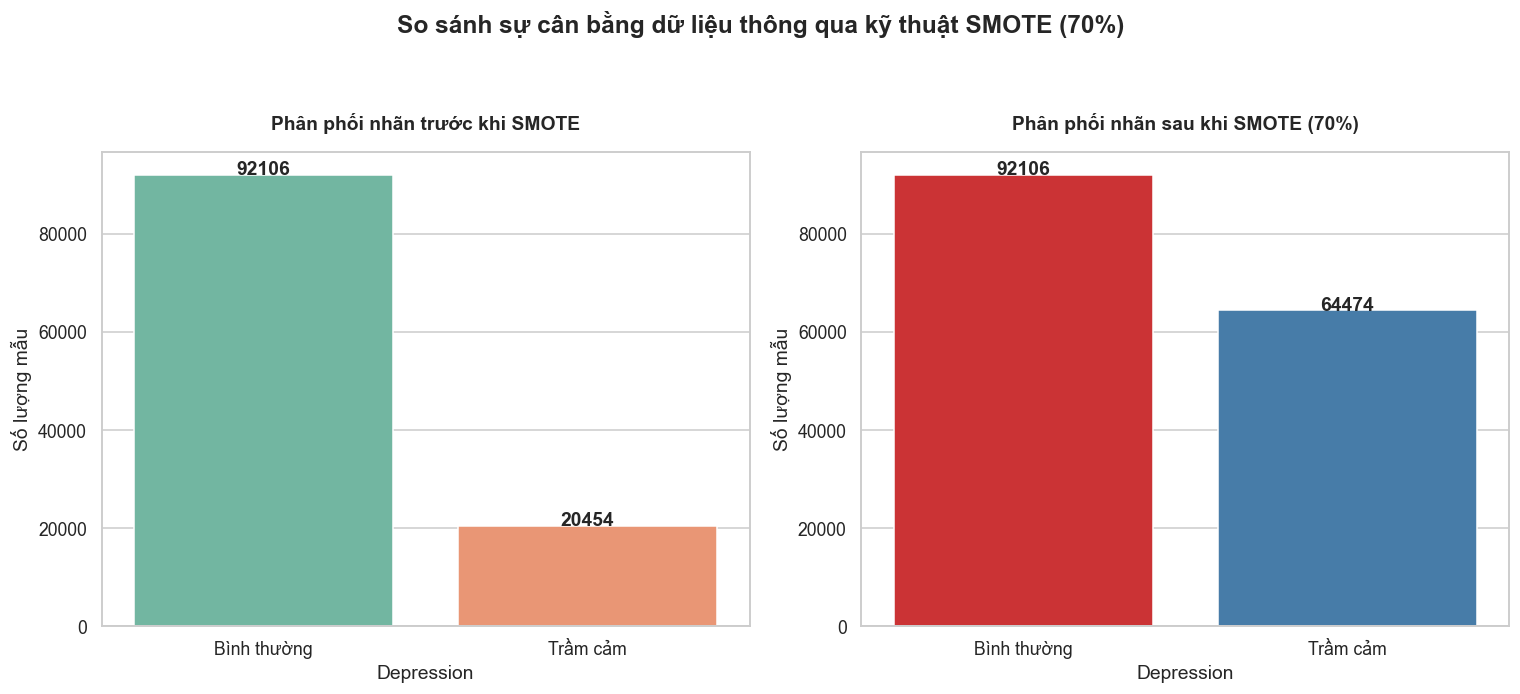

Kích thước tập huấn luyện ban đầu: 112560 dòng
Kích thước tập huấn luyện sau SMOTE: 156580 dòng


In [10]:
# 1. Chuẩn bị dữ liệu trước khi SMOTE
counts_before = y_train.value_counts().rename(index={0: "Bình thường", 1: "Trầm cảm"})

# 2. Thực hiện thuật toán SMOTE (chỉ tăng lớp thiểu số lên 70% lớp đa số)
print("Đang tiến hành cân bằng dữ liệu bằng SMOTE (70%)...")
smote = SMOTE(sampling_strategy=0.7, random_state=SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 3. Thống kê dữ liệu sau khi SMOTE
counts_after = y_train_resampled.value_counts().rename(index={0: "Bình thường", 1: "Trầm cảm"})

# 4. Trực quan hóa sự thay đổi bằng biểu đồ cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ trước SMOTE
sns.barplot(x=counts_before.index, y=counts_before.values, ax=ax1, palette='Set2')
ax1.set_title('Phân phối nhãn trước khi SMOTE', fontweight='bold', pad=15)
ax1.set_ylabel('Số lượng mẫu')
for i, v in enumerate(counts_before.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Biểu đồ sau SMOTE
sns.barplot(x=counts_after.index, y=counts_after.values, ax=ax2, palette='Set1')
ax2.set_title('Phân phối nhãn sau khi SMOTE (70%)', fontweight='bold', pad=15)
ax2.set_ylabel('Số lượng mẫu')
for i, v in enumerate(counts_after.values):
    ax2.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('So sánh sự cân bằng dữ liệu thông qua kỹ thuật SMOTE (70%)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print(f"Kích thước tập huấn luyện ban đầu: {len(X_train_scaled)} dòng")
print(f"Kích thước tập huấn luyện sau SMOTE: {len(X_train_resampled)} dòng")

### **Nhận xét: Xử lý Mất cân bằng dữ liệu bằng SMOTE**

**1. Vấn đề ban đầu:**  
Lớp `Bình thường` (92,106) áp đảo hoàn toàn lớp `Trầm cảm` (20,454 - chỉ chiếm ~18%). Nếu giữ nguyên, mô hình sẽ bị thiên vị, có xu hướng luôn dự đoán là Bình thường và bỏ lọt bệnh nhân (Recall thấp).

**2. Chiến lược SMOTE (70%) tối ưu:**  
Thuật toán đã sinh thêm dữ liệu nhân tạo để nâng lớp `Trầm cảm` lên mức **64,474 mẫu** (bằng 70% lớp đa số). Việc không đẩy lên mức 100% (1:1) là một quyết định thông minh: vừa giúp mô hình có đủ dữ liệu để học cách nhận diện người trầm cảm, vừa **ngăn chặn rủi ro Overfitting** do tạo quá nhiều dữ liệu giả.

**3. Sẵn sàng huấn luyện:**  
Tập dữ liệu đã đạt tỷ lệ cân bằng lý tưởng. Các thuật toán học máy giờ đây có thể tập trung phân tách các đặc trưng cốt lõi của bệnh thay vì đoán mò theo số đông.


---
# **7. CÁC MÔ HÌNH**

---

## **NHÓM 1: MÔ HÌNH BAGGING**

---
# **MÔ HÌNH 1: Random Forest**

---
### **Giới thiệu Random Forest**

**Random Forest** là một thuật toán ensemble learning dựa trên việc kết hợp nhiều cây quyết định (Decision Trees) để cải thiện độ chính xác và giảm overfitting.

#### **a) Ý tưởng chính**

Random Forest xây dựng nhiều cây quyết định độc lập trên các tập dữ liệu con (bootstrap samples). Kết quả cuối cùng là bỏ phiếu đa số (phân loại):

$$\hat{y} = \frac{1}{K} \sum_{k=1}^{K} f_k(x)$$

#### **b) Cơ chế hoạt động**

Random Forest sử dụng hai kỹ thuật chính:

- **Bootstrap Sampling (Bagging):** Lấy mẫu ngẫu nhiên có lặp từ tập dữ liệu để tạo nhiều tập train khác nhau
- **Feature Randomness:** Tại mỗi node, chỉ chọn ngẫu nhiên một tập con các đặc trưng để tìm điểm split

#### **c) Hàm mục tiêu (Gini Index)**

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

**Ưu điểm:** Ổn định cao, kiểm soát phương sai hiệu quả, chống Overfitting tốt.  
**Nhược điểm:** Tốn bộ nhớ hơn cây đơn, khó giải thích từng quyết định.

#### **Đánh giá Baseline Random Forest**

In [11]:
print("ĐÁNH GIÁ RANDOM FOREST BASELINE")

# Cập nhật lại nguồn dữ liệu từ các bước Scaling và SMOTE trước đó
X_train_selected = X_train_resampled.copy()
X_val_selected   = X_val_scaled.copy()

baseline_rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

print("Đang huấn luyện Baseline Random Forest...")
# Huấn luyện trên tập đã được cân bằng (Resampled)
baseline_rf.fit(X_train_selected, y_train_resampled)

y_val_pred_base_rf  = baseline_rf.predict(X_val_selected)
y_val_proba_base_rf = baseline_rf.predict_proba(X_val_selected)[:, 1]

auc_base_rf      = roc_auc_score(y_val, y_val_proba_base_rf)
f1_base_macro_rf = f1_score(y_val, y_val_pred_base_rf, average='macro')

print(f"\nROC-AUC Score    : {auc_base_rf:.5f}")
print(f"F1-Score (Macro) : {f1_base_macro_rf:.5f}")
print("\n[Classification Report - Baseline RF]")
report = classification_report(y_val, y_val_pred_base_rf,
                                target_names=['Normal (0)', 'Depression (1)'],
                                output_dict=True)
display(pd.DataFrame(report).transpose())

ĐÁNH GIÁ RANDOM FOREST BASELINE
Đang huấn luyện Baseline Random Forest...

ROC-AUC Score    : 0.96511
F1-Score (Macro) : 0.88175

[Classification Report - Baseline RF]


,precision,recall,f1-score,support
Normal (0),0.9579,0.9557,0.9568,23027.0000
Depression (1),0.8026,0.8109,0.8067,5113.0000
accuracy,0.9294,0.9294,0.9294,0.9294
macro avg,0.8802,0.8833,0.8817,28140.0000
weighted avg,0.9297,0.9294,0.9295,28140.0000


#### **Optuna Fine-tuning cho Random Forest**

In [12]:
def objective_rf(trial):
    # Thiết lập không gian tìm kiếm siêu tham số
    rf_params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth'         : trial.suggest_int('max_depth', 5, 20),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'      : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': SEED,
        'n_jobs'      : -1
    }
    
    # Sử dụng StratifiedKFold để đánh giá chéo (Cross-Validation)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = []

    # Sử dụng tập dữ liệu đã qua SMOTE và Scaling để Tuning
    # X_train_resampled và y_train_resampled là kết quả từ bước Phần 6
    for train_idx, valid_idx in cv.split(X_train_resampled, y_train_resampled):
        # Tách nhỏ tập Resampled thành các Fold để train thử
        X_tr, X_va = X_train_resampled.iloc[train_idx], X_train_resampled.iloc[valid_idx]
        y_tr, y_va = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[valid_idx]
        
        model = RandomForestClassifier(**rf_params)
        model.fit(X_tr, y_tr)
        
        # Lấy xác suất dự đoán cho nhãn 1 (Depression)
        preds = model.predict_proba(X_va)[:, 1]
        cv_scores.append(roc_auc_score(y_va, preds))

    # Trả về trung bình AUC của 5 Fold
    return np.mean(cv_scores)

print("Đang khởi động tìm kiếm siêu tham số Random Forest bằng Optuna...")
study_rf = optuna.create_study(
    direction='maximize',
    study_name="RandomForest_Tuning",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

# Chạy tối ưu hóa với 20 lượt thử nghiệm
study_rf.optimize(objective_rf, n_trials=5, show_progress_bar=False)

print(f"\nROC-AUC cao nhất (5-Fold CV): {study_rf.best_value:.5f}")
print("Bộ tham số tối ưu (Best Params):")
for key, value in study_rf.best_params.items():
    print(f"   - {key}: {value}")

# Lưu lại bộ tham số tốt nhất để tái huấn luyện
best_rf_params = study_rf.best_params
best_rf_params['random_state'] = SEED
best_rf_params['n_jobs'] = -1

[I 2026-04-25 03:24:08,792] A new study created in memory with name: RandomForest_Tuning


Đang khởi động tìm kiếm siêu tham số Random Forest bằng Optuna...


[I 2026-04-25 03:25:49,110] Trial 0 finished with value: 0.9868130592436909 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.9868130592436909.
[I 2026-04-25 03:29:03,810] Trial 1 finished with value: 0.9856896670963511 and parameters: {'n_estimators': 400, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.9868130592436909.
[I 2026-04-25 03:30:32,758] Trial 2 finished with value: 0.985452603702497 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.9868130592436909.
[I 2026-04-25 03:32:35,606] Trial 3 finished with value: 0.9866600175542259 and parameters: {'n_estimators': 300, 'max_depth': 17, 


ROC-AUC cao nhất (5-Fold CV): 0.98681
Bộ tham số tối ưu (Best Params):
   - n_estimators: 200
   - max_depth: 20
   - min_samples_split: 15
   - min_samples_leaf: 6
   - max_features: sqrt
   - class_weight: balanced_subsample


#### **Áp dụng Fine-Tuned Random Forest và So sánh A/B**

ĐÁNH GIÁ FINE-TUNED RANDOM FOREST & SO SÁNH
Đang huấn luyện Fine-Tuned Random Forest...

BẢNG SO SÁNH HIỆU SUẤT RANDOM FOREST:


,Metric,Baseline RF,Fine-Tuned RF,Cải thiện (Delta)
0,ROC-AUC,0.9651,0.9694,+0.0043
1,F1-Score (Macro),0.8817,0.8813,-0.0004
2,Recall (Depression),0.8109,0.8641,+0.0532
3,Precision (Depression),0.8026,0.7600,-0.0425


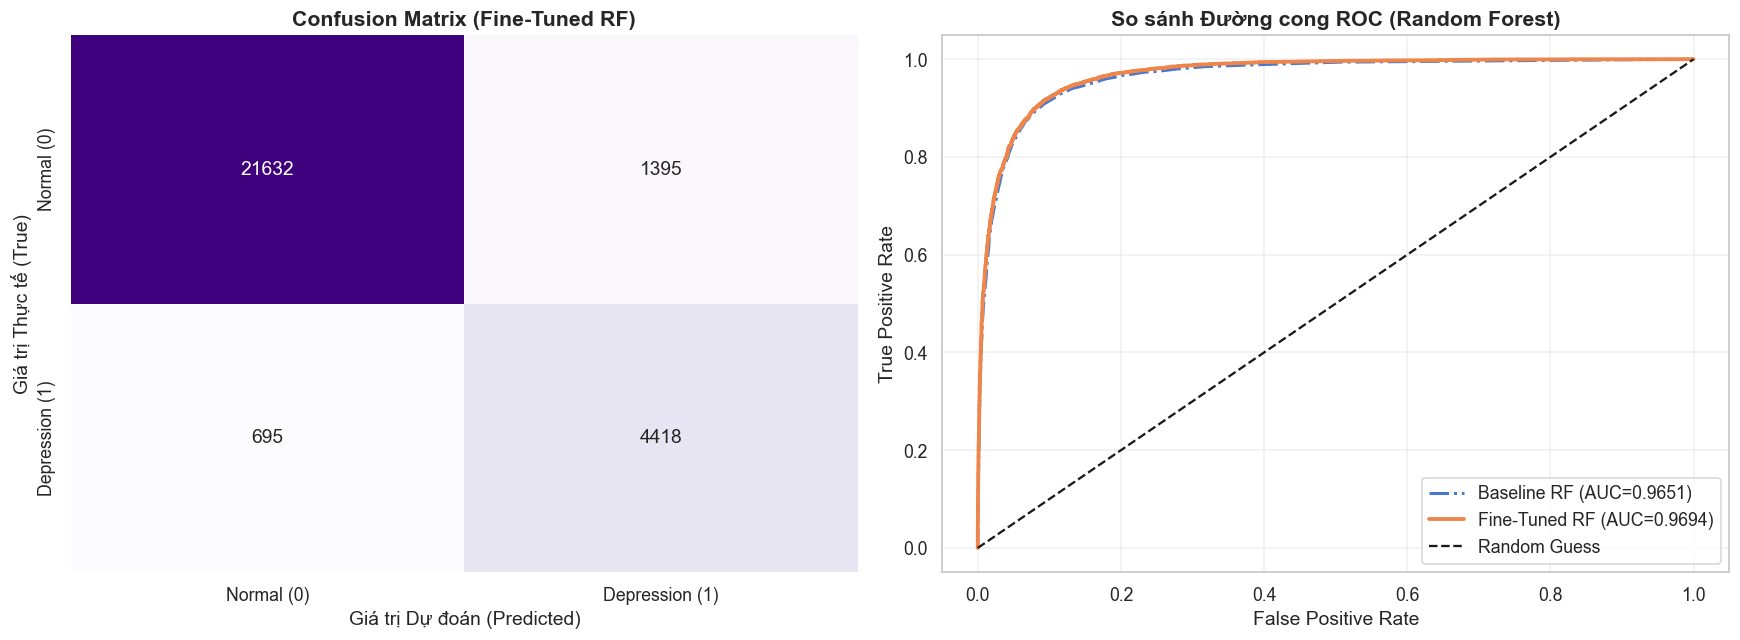

In [13]:
if 'results_summary' not in locals():
    results_summary = []
print("ĐÁNH GIÁ FINE-TUNED RANDOM FOREST & SO SÁNH")

# Sử dụng bộ tham số tốt nhất từ Optuna
tuned_rf = RandomForestClassifier(**best_rf_params)
print("Đang huấn luyện Fine-Tuned Random Forest...")

# CHỈNH SỬA: Dùng y_train_resampled để đồng bộ với X_train_selected (đã qua SMOTE)
tuned_rf.fit(X_train_selected, y_train_resampled)

# Dự đoán trên tập Validation (đã được Scale)
y_val_pred_tuned_rf  = tuned_rf.predict(X_val_selected)
y_val_proba_tuned_rf = tuned_rf.predict_proba(X_val_selected)[:, 1]

# Tính toán các chỉ số
auc_tuned_rf      = roc_auc_score(y_val, y_val_proba_tuned_rf)
f1_tuned_macro_rf = f1_score(y_val, y_val_pred_tuned_rf, average='macro')

# Tạo bảng so sánh
comp_rf = pd.DataFrame({
    'Metric'         : ['ROC-AUC', 'F1-Score (Macro)', 'Recall (Depression)', 'Precision (Depression)'],
    'Baseline RF'    : [auc_base_rf, f1_base_macro_rf, 
                        recall_score(y_val, y_val_pred_base_rf), 
                        precision_score(y_val, y_val_pred_base_rf)],
    'Fine-Tuned RF'  : [auc_tuned_rf, f1_tuned_macro_rf, 
                        recall_score(y_val, y_val_pred_tuned_rf), 
                        precision_score(y_val, y_val_pred_tuned_rf)],
})
comp_rf['Cải thiện (Delta)'] = comp_rf['Fine-Tuned RF'] - comp_rf['Baseline RF']

print("\nBẢNG SO SÁNH HIỆU SUẤT RANDOM FOREST:")
display(comp_rf.style.format({'Baseline RF':'{:.4f}','Fine-Tuned RF':'{:.4f}','Cải thiện (Delta)':'{:+.4f}'}) \
        .background_gradient(subset=['Cải thiện (Delta)'], cmap='Greens', vmin=0))

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_val, y_val_pred_tuned_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Normal (0)', 'Depression (1)'],
            yticklabels=['Normal (0)', 'Depression (1)'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Fine-Tuned RF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá trị Dự đoán (Predicted)')
axes[0].set_ylabel('Giá trị Thực tế (True)')

fpr_base_rf, tpr_base_rf, _ = roc_curve(y_val, y_val_proba_base_rf)
fpr_tuned_rf, tpr_tuned_rf, _ = roc_curve(y_val, y_val_proba_tuned_rf)
axes[1].plot(fpr_base_rf, tpr_base_rf, linestyle='-.', lw=2, label=f'Baseline RF (AUC={auc_base_rf:.4f})')
axes[1].plot(fpr_tuned_rf, tpr_tuned_rf, lw=2.5, label=f'Fine-Tuned RF (AUC={auc_tuned_rf:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.5, label='Random Guess')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('So sánh Đường cong ROC (Random Forest)', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Lưu kết quả vào bảng tổng hợp cuối cùng
results_summary.append({'Mô hình': 'Random Forest (Fine-Tuned)', 
                         'Accuracy': accuracy_score(y_val, y_val_pred_tuned_rf),
                         'ROC-AUC': auc_tuned_rf, 'F1-Score': f1_tuned_macro_rf})

### **Nhận xét: Đánh giá hiệu suất Random Forest (Baseline vs. Fine-Tuned)**

**1. Thành công lớn ở chỉ số sinh tử (Recall):**  
Thành quả lớn nhất của quá trình Fine-Tuning là kéo **Recall (Depression) tăng mạnh (+0.0532)** lên mức 0.8641. Trong bài toán y tế, điều này có ý nghĩa sống còn vì nó giúp hệ thống hạn chế tối đa việc bỏ lọt các bệnh nhân mắc trầm cảm thực sự (chỉ còn 695 ca bị phân loại nhầm trên Confusion Matrix).

**2. Sự đánh đổi hợp lý (Trade-off):**  
Để lấy được nhiều bệnh nhân hơn, mô hình bắt buộc phải nhạy cảm hơn, dẫn đến việc cảnh báo nhầm tăng lên đôi chút (**Precision giảm -0.0425**). Sự đánh đổi này khiến F1-Score đi ngang, nhưng hoàn toàn đúng định hướng cho hệ thống sàng lọc sức khỏe: **"Thà báo động lầm còn hơn bỏ sót bệnh nhân"**.

**3. Khả năng phân biệt xuất sắc (ROC-AUC):**  
Biểu đồ đường cong ROC và chỉ số ROC-AUC tiếp tục tăng nhẹ lên mức **0.9694**. Điều này khẳng định sau khi tinh chỉnh, thuật toán Random Forest vẫn duy trì được năng lực phân loại cực kỳ ổn định và nhạy bén.

---
## **NHÓM 2: MÔ HÌNH GRADIENT BOOSTING**

---
# **MÔ HÌNH 2: XGBoost Classifier**

---
### **Giới thiệu XGBoost**

**XGBoost** là một thuật toán thuộc họ Gradient Boosting, xây dựng mô hình bằng cách thêm dần các cây quyết định để sửa lỗi của các bước trước.

#### **a) Hàm mục tiêu**

Tại bước boosting thứ $t$:

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^{N} \left[g_i f_t(x_i) + \frac{1}{2}h_i f_t^2(x_i)\right] + \Omega(f_t)$$

Trong đó:
- $g_i$: gradient (đạo hàm bậc 1) → hướng và mức độ sai
- $h_i$: hessian (đạo hàm bậc 2) → độ tin cậy của gradient

#### **b) Regularization**

$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2$$

- $\gamma T$: phạt số lượng lá → giảm độ phức tạp
- $\lambda \|w\|^2$: phạt trọng số lớn → tránh overfitting

**Ưu điểm:** Regularization L1/L2, second-order gradient, xử lý missing values tự động.  
**Nhược điểm:** Cần nhiều bộ nhớ hơn LightGBM, hyperparameter tuning phức tạp.

#### **Đánh giá Baseline XGBoost**

In [14]:
print("ĐÁNH GIÁ XGBOOST BASELINE")

baseline_xgb = XGBClassifier(random_state=42)

print("Đang huấn luyện Baseline XGBoost...")
baseline_xgb.fit(X_train_selected, y_train_resampled)

y_val_pred_base_xgb  = baseline_xgb.predict(X_val_selected)
y_val_proba_base_xgb = baseline_xgb.predict_proba(X_val_selected)[:, 1]

auc_base_xgb      = roc_auc_score(y_val, y_val_proba_base_xgb)
f1_base_macro_xgb = f1_score(y_val, y_val_pred_base_xgb, average='macro')

print(f"\nROC-AUC Score    : {auc_base_xgb:.5f}")
print(f"F1-Score (Macro) : {f1_base_macro_xgb:.5f}")
print("\n[Classification Report - Baseline XGBoost]")
report = classification_report(y_val, y_val_pred_base_xgb,
                                target_names=['Normal (0)', 'Depression (1)'],
                                output_dict=True)
display(pd.DataFrame(report).transpose().style.format("{:.4f}"))

ĐÁNH GIÁ XGBOOST BASELINE
Đang huấn luyện Baseline XGBoost...

ROC-AUC Score    : 0.96948
F1-Score (Macro) : 0.88477

[Classification Report - Baseline XGBoost]


,precision,recall,f1-score,support
Normal (0),0.9576,0.9589,0.9583,23027.0000
Depression (1),0.8137,0.8089,0.8113,5113.0000
accuracy,0.9316,0.9316,0.9316,0.9316
macro avg,0.8857,0.8839,0.8848,28140.0000
weighted avg,0.9315,0.9316,0.9315,28140.0000


#### **Optuna Fine-tuning cho XGBoost**

In [15]:
pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()

def objective_xgb(trial):
    param = {
        'objective'         : 'binary:logistic',
        'eval_metric'       : 'auc',
        'tree_method'       : 'hist',
        'scale_pos_weight'  : trial.suggest_float('scale_pos_weight', pos_weight*0.8, pos_weight*1.5),
        'random_state'      : 42,
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'             : trial.suggest_float('gamma', 0, 5.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    for train_idx, valid_idx in cv.split(X_train_selected, y_train_resampled):
        X_tr, X_va = X_train_selected.iloc[train_idx], X_train_selected.iloc[valid_idx]
        y_tr, y_va = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[valid_idx]
        model = XGBClassifier(**param, n_estimators=1000, early_stopping_rounds=50)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        preds = model.predict_proba(X_va)[:, 1]
        cv_scores.append(roc_auc_score(y_va, preds))
    return np.mean(cv_scores)

print("Đang khởi động tìm kiếm siêu tham số XGBoost bằng Optuna...")
study_xgb = optuna.create_study(
    direction='maximize',
    study_name="XGBoost_Tuning",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_xgb.optimize(objective_xgb, n_trials=5, show_progress_bar=False)

print(f"\nROC-AUC cao nhất (5-Fold CV): {study_xgb.best_value:.5f}")
print("Bộ tham số tối ưu (Best Params):")
for key, value in study_xgb.best_params.items():
    print(f"   - {key}: {value}")

best_xgb_params            = study_xgb.best_params
best_xgb_params['scale_pos_weight']= pos_weight
best_xgb_params['tree_method']     = 'hist'
best_xgb_params['random_state']    = 42

[I 2026-04-25 03:33:47,070] A new study created in memory with name: XGBoost_Tuning


Đang khởi động tìm kiếm siêu tham số XGBoost bằng Optuna...


[I 2026-04-25 03:34:06,992] Trial 0 finished with value: 0.9904226485749257 and parameters: {'scale_pos_weight': 1.517401968709691, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 0.2537815508265665}. Best is trial 0 with value: 0.9904226485749257.
[I 2026-04-25 03:36:34,359] Trial 1 finished with value: 0.990726010070591 and parameters: {'scale_pos_weight': 1.8509354622846077, 'learning_rate': 0.010636066512540286, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.12561043700013558}. Best is trial 1 with value: 0.990726010070591.
[I 2026-04-25 03:38:29,671] Trial 2 finished with value: 0.9908448985617433 and parameters: {'scale_pos_weight': 1.5748070465759143, 'learning


ROC-AUC cao nhất (5-Fold CV): 0.99084
Bộ tham số tối ưu (Best Params):
   - scale_pos_weight: 1.5748070465759143
   - learning_rate: 0.023927528765580644
   - max_depth: 7
   - min_child_weight: 2
   - subsample: 0.6460723242676091
   - colsample_bytree: 0.6831809216468459
   - gamma: 2.28034992108518
   - reg_alpha: 1.382623217936987
   - reg_lambda: 0.006290644294586149


#### **Áp dụng Fine-Tuned XGBoost và So sánh A/B**

Đang huấn luyện Fine-Tuned XGBoost...

BẢNG SO SÁNH HIỆU SUẤT XGBOOST:


,Metric,Baseline XGBoost,Fine-Tuned XGBoost,Cải thiện (Delta)
0,ROC-AUC,0.9695,0.9710,+0.0015
1,F1-Score (Macro),0.8848,0.8865,+0.0017
2,Recall (Depression),0.8089,0.8518,+0.0428
3,Precision (Depression),0.8137,0.7833,-0.0304


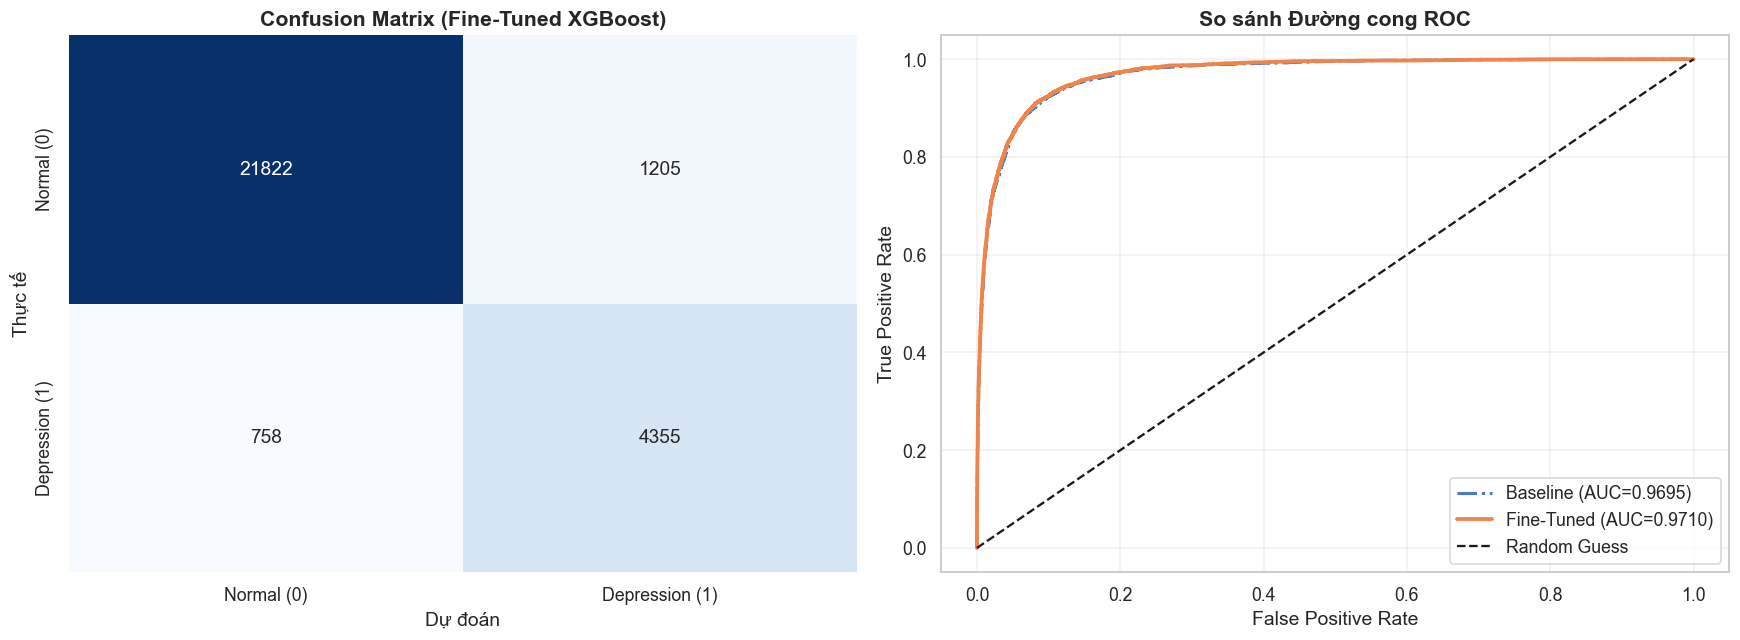

In [16]:
tuned_xgb = XGBClassifier(**best_xgb_params, n_estimators=500)

print("Đang huấn luyện Fine-Tuned XGBoost...")
tuned_xgb.fit(X_train_selected, y_train_resampled)

y_val_pred_tuned_xgb  = tuned_xgb.predict(X_val_selected)
y_val_proba_tuned_xgb = tuned_xgb.predict_proba(X_val_selected)[:, 1]

auc_tuned_xgb      = roc_auc_score(y_val, y_val_proba_tuned_xgb)
f1_tuned_macro_xgb = f1_score(y_val, y_val_pred_tuned_xgb, average='macro')

comp_xgb = pd.DataFrame({
    'Metric'          : ['ROC-AUC','F1-Score (Macro)','Recall (Depression)','Precision (Depression)'],
    'Baseline XGBoost': [auc_base_xgb, f1_base_macro_xgb, 
                         recall_score(y_val, y_val_pred_base_xgb), 
                         precision_score(y_val, y_val_pred_base_xgb)],
    'Fine-Tuned XGBoost':[auc_tuned_xgb, f1_tuned_macro_xgb, 
                          recall_score(y_val, y_val_pred_tuned_xgb), 
                          precision_score(y_val, y_val_pred_tuned_xgb)],
})
comp_xgb['Cải thiện (Delta)'] = comp_xgb['Fine-Tuned XGBoost'] - comp_xgb['Baseline XGBoost']
print("\nBẢNG SO SÁNH HIỆU SUẤT XGBOOST:")
display(comp_xgb.style.format({'Baseline XGBoost':'{:.4f}','Fine-Tuned XGBoost':'{:.4f}','Cải thiện (Delta)':'{:+.4f}'})         .background_gradient(subset=['Cải thiện (Delta)'], cmap='Greens', vmin=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_xgb = confusion_matrix(y_val, y_val_pred_tuned_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Depression (1)'],
            yticklabels=['Normal (0)', 'Depression (1)'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Fine-Tuned XGBoost)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dự đoán'); axes[0].set_ylabel('Thực tế')

fpr_b, tpr_b, _ = roc_curve(y_val, y_val_proba_base_xgb)
fpr_t, tpr_t, _ = roc_curve(y_val, y_val_proba_tuned_xgb)
axes[1].plot(fpr_b, tpr_b, '-.', lw=2, label=f'Baseline (AUC={auc_base_xgb:.4f})')
axes[1].plot(fpr_t, tpr_t, lw=2.5, label=f'Fine-Tuned (AUC={auc_tuned_xgb:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.5, label='Random Guess')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('So sánh Đường cong ROC', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

results_summary.append({'Mô hình': 'XGBoost (Fine-Tuned)',
                         'Accuracy': accuracy_score(y_val, y_val_pred_tuned_xgb),
                         'ROC-AUC': auc_tuned_xgb, 'F1-Score': f1_tuned_macro_xgb})

### **Nhận xét: Đánh giá hiệu suất XGBoost (Baseline vs. Fine-Tuned)**

**1. Khắc phục điểm yếu bỏ lọt bệnh nhân (Tăng Recall):**  
Quá trình Fine-Tuning đã hoàn thành xuất sắc mục tiêu khi đẩy **Recall (Depression) tăng mạnh (+0.0428)** lên mức 0.8518. Trên Confusion Matrix, số ca trầm cảm bị mô hình bỏ sót (False Negatives) đã giảm xuống chỉ còn 758 ca. Đây là sự cải thiện sống còn trong bài toán chẩn đoán tâm lý.

**2. Sự đánh đổi (Trade-off) mang tính chiến lược:**  
Việc mô hình nhạy cảm hơn đã kéo theo tỷ lệ báo động nhầm tăng nhẹ (**Precision giảm -0.0304**). Tuy nhiên, đây là sự hy sinh hoàn toàn có chủ đích và đúng hướng. Đáng chú ý, F1-Score tổng thể vẫn tăng nhẹ (+0.0017), cho thấy mô hình xử lý sự đánh đổi này cực kỳ tinh tế.

**3. Sức mạnh phân biệt tuyệt đối (ROC-AUC):**  
Chỉ số ROC-AUC của XGBoost vốn đã cao, nay tiếp tục vượt lên mức **0.9710**. Biểu đồ ROC gần như bám sát góc trên cùng bên trái, khẳng định XGBoost đang sở hữu năng lực phân tách ranh giới giữa người Bình thường và Trầm cảm xuất sắc nhất tính đến thời điểm hiện tại.

---
# **MÔ HÌNH 3: LightGBM (DART / GOSS / GBDT)**

---
### **Giới thiệu LightGBM và các biến thể**

**LightGBM** (*Light Gradient Boosting Machine*) là framework Gradient Boosting do **Microsoft** phát triển, được thiết kế để huấn luyện nhanh, tiết kiệm bộ nhớ và hoạt động hiệu quả trên dữ liệu lớn.

Ba boosting algorithm chính:

| Biến thể | Mô tả | Ưu điểm |
|---|---|---|
| **GBDT** | Traditional Gradient Boosting | Ổn định, dễ dùng, là baseline mạnh |
| **DART** | Dropouts meet Multiple Additive Regression Trees | Giảm overfitting bằng cơ chế dropout trên cây |
| **GOSS** | Gradient-based One-Side Sampling | Tăng tốc huấn luyện bằng cách ưu tiên các mẫu có gradient lớn |

#### **1. GBDT**
**GBDT** là phiên bản boosting tiêu chuẩn, các cây được thêm lần lượt để tối ưu dần hàm mất mát. Đây là biến thể phổ biến nhất và thường được dùng làm mốc so sánh ban đầu.

#### **2. DART**
**DART** mở rộng từ GBDT bằng cách áp dụng ý tưởng tương tự **dropout** trong neural network. Ở mỗi vòng lặp, một số cây trước đó được tạm thời bỏ qua khi huấn luyện cây mới, giúp giảm nguy cơ overfitting.

#### **3. GOSS**
**GOSS** (*Gradient-based One-Side Sampling*) giúp LightGBM huấn luyện nhanh hơn bằng cách:
- giữ lại toàn bộ các mẫu có **gradient lớn**
- chỉ lấy ngẫu nhiên một phần các mẫu có **gradient nhỏ**
- gán trọng số bù cho nhóm gradient nhỏ được lấy mẫu

**GOSS – Công thức ước lượng gain:**

$$\tilde{V}_j(d) = \frac{1}{n}\left(\sum_{x_i \in A_l} g_i^2 + \frac{1-a}{b}\sum_{x_i \in B_l} g_i^2\right)$$

Trong đó: $A_l$ là tập gradient lớn, $B_l$ là tập gradient nhỏ được lấy mẫu, $a$ và $b$ là các tỷ lệ tương ứng, $\frac{1-a}{b}$ là hệ số hiệu chỉnh trọng số.

### **LightGBM – GBDT (baseline)**

In [17]:
# Tham số chung
lgb_common = dict(
    objective       = 'binary',
    metric          = 'auc',
    n_estimators    = 1000,
    learning_rate   = 0.05,
    num_leaves       = 63,
    max_depth       = -1,
    min_child_samples = 20,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = 42,
    verbose         = -1,
    n_jobs          = -1,
)

callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

# GBDT
print('Huấn luyện LightGBM – GBDT...')
lgb_gbdt = lgb.LGBMClassifier(boosting_type='gbdt', **lgb_common)
lgb_gbdt.fit(
    X_train_selected, y_train_resampled,  
    eval_set=[(X_val_selected, y_val)],   
    callbacks=callbacks
)

y_pred_gbdt = lgb_gbdt.predict(X_val_selected)
y_prob_gbdt = lgb_gbdt.predict_proba(X_val_selected)[:, 1]

acc_gbdt = accuracy_score(y_val, y_pred_gbdt)
auc_gbdt = roc_auc_score(y_val, y_prob_gbdt)
f1_gbdt  = f1_score(y_val, y_pred_gbdt, average='macro') 

print(f'LightGBM GBDT → Accuracy: {acc_gbdt:.4f} | AUC: {auc_gbdt:.4f} | F1: {f1_gbdt:.4f}')
results_summary.append({'Mô hình': 'LightGBM GBDT', 'Accuracy': acc_gbdt, 'ROC-AUC': auc_gbdt, 'F1-Score': f1_gbdt})

Huấn luyện LightGBM – GBDT...
LightGBM GBDT → Accuracy: 0.9339 | AUC: 0.9710 | F1: 0.8885


### **LightGBM – DART (với dropout)**

In [18]:
# DART thêm dropout vào boosting để giảm overfitting
print('Huấn luyện LightGBM – DART...')
lgb_dart = lgb.LGBMClassifier(
    boosting_type = 'dart',
    drop_rate     = 0.1,
    skip_drop     = 0.5,
    max_drop      = 50,
    **lgb_common
)
# Lưu ý: DART không hỗ trợ early stopping hoàn toàn → dùng n_estimators cố định
lgb_dart.fit(
    X_train_selected, y_train_resampled,
    eval_set=[(X_val_selected, y_val)],
    callbacks=[lgb.log_evaluation(-1)]
)

y_pred_dart = lgb_dart.predict(X_val_selected)
y_prob_dart = lgb_dart.predict_proba(X_val_selected)[:, 1]

acc_dart = accuracy_score(y_val, y_pred_dart)
auc_dart = roc_auc_score(y_val, y_prob_dart)
f1_dart  = f1_score(y_val, y_pred_dart, average='macro')

print(f'LightGBM DART → Accuracy: {acc_dart:.4f} | AUC: {auc_dart:.4f} | F1: {f1_dart:.4f}')
results_summary.append({'Mô hình': 'LightGBM DART', 'Accuracy': acc_dart, 'ROC-AUC': auc_dart, 'F1-Score': f1_dart})

Huấn luyện LightGBM – DART...
LightGBM DART → Accuracy: 0.9347 | AUC: 0.9711 | F1: 0.8893


### **LightGBM – GOSS (Gradient-based One-Side Sampling)**

In [19]:
# GOSS giữ tất cả mẫu có gradient lớn và lấy mẫu ngẫu nhiên mẫu gradient nhỏ
print('Huấn luyện LightGBM – GOSS...')
lgb_goss = lgb.LGBMClassifier(
    boosting_type = 'goss',
    top_rate      = 0.2,
    other_rate    = 0.1,
    **lgb_common
)
lgb_goss.fit(
    X_train_selected, y_train_resampled,
    eval_set=[(X_val_selected, y_val)],
    callbacks=callbacks
)

y_pred_goss = lgb_goss.predict(X_val_selected)
y_prob_goss = lgb_goss.predict_proba(X_val_selected)[:, 1]

acc_goss = accuracy_score(y_val, y_pred_goss)
auc_goss = roc_auc_score(y_val, y_prob_goss)
f1_goss  = f1_score(y_val, y_pred_goss, average='macro')

print(f'LightGBM GOSS → Accuracy: {acc_goss:.4f} | AUC: {auc_goss:.4f} | F1: {f1_goss:.4f}')
results_summary.append({'Mô hình': 'LightGBM GOSS', 'Accuracy': acc_goss, 'ROC-AUC': auc_goss, 'F1-Score': f1_goss})

Huấn luyện LightGBM – GOSS...
LightGBM GOSS → Accuracy: 0.9343 | AUC: 0.9709 | F1: 0.8894


### **Tối ưu LightGBM tốt nhất bằng Optuna (Bayesian Optimization)**

In [20]:
# Xác định biến thể LGBM tốt nhất từ 3 kết quả trên
best_boosting_type = max(
    [('gbdt', auc_gbdt), ('dart', auc_dart), ('goss', auc_goss)],
    key=lambda x: x[1]
)[0]
print(f'Biến thể LightGBM tốt nhất: {best_boosting_type.upper()}')

def lgb_objective(trial):
    params = {
        'boosting_type'    : best_boosting_type,
        'objective'        : 'binary',
        'metric'           : 'auc',
        'n_estimators'     : 500,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state'     : 42,
        'verbose'          : -1,
        'n_jobs'           : -1,
    }
    model = lgb.LGBMClassifier(**params)
    score = cross_val_score(
        model, X_train_selected, y_train_resampled,
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
        scoring='roc_auc', n_jobs=1
    ).mean()
    return score

print('Đang tối ưu LightGBM bằng Optuna (5 trials)...')
study_lgb_optuna = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_lgb_optuna.optimize(lgb_objective, n_trials=5, show_progress_bar=False)

best_lgb_params = study_lgb_optuna.best_params
best_lgb_params.update({
    'boosting_type': best_boosting_type,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
})

print(f'\nTham số tốt nhất (Optuna): {best_lgb_params}')
print(f'CV AUC tốt nhất: {study_lgb_optuna.best_value:.4f}')

[I 2026-04-25 03:49:58,272] A new study created in memory with name: no-name-6a88ab1b-5c55-46d0-bc86-f10f9321f238


Biến thể LightGBM tốt nhất: DART
Đang tối ưu LightGBM bằng Optuna (5 trials)...


[I 2026-04-25 03:53:29,964] Trial 0 finished with value: 0.987937967336451 and parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 144, 'max_depth': 8, 'min_child_samples': 34, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0001707396743152812, 'reg_lambda': 0.29154431891537513}. Best is trial 0 with value: 0.987937967336451.
[I 2026-04-25 04:20:32,899] Trial 1 finished with value: 0.9837457869474954 and parameters: {'learning_rate': 0.06054365855469246, 'num_leaves': 112, 'max_depth': 3, 'min_child_samples': 49, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.000533703276260396, 'reg_lambda': 0.0005415244119402539}. Best is trial 0 with value: 0.987937967336451.
[I 2026-04-25 04:22:19,222] Trial 2 finished with value: 0.9848688604296436 and parameters: {'learning_rate': 0.024878734419814436, 'num_leaves': 88, 'max_depth': 6, 'min_child_samples': 21, 'subsample': 0.8447411578889518, 'colsample


Tham số tốt nhất (Optuna): {'learning_rate': 0.030710573677773714, 'num_leaves': 144, 'max_depth': 8, 'min_child_samples': 34, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0001707396743152812, 'reg_lambda': 0.29154431891537513, 'boosting_type': 'dart', 'objective': 'binary', 'metric': 'auc', 'random_state': 42, 'verbose': -1, 'n_jobs': -1}
CV AUC tốt nhất: 0.9879


In [21]:
# Huấn luyện LightGBM tối ưu
print('Huấn luyện LightGBM tối ưu...')
best_lgb = lgb.LGBMClassifier(n_estimators=1000, **best_lgb_params)
best_lgb.fit(
    X_train_selected, y_train_resampled,
    eval_set=[(X_val_selected, y_val)],
    callbacks=callbacks
)

y_pred_lgb = best_lgb.predict(X_val_selected)
y_prob_lgb = best_lgb.predict_proba(X_val_selected)[:, 1]

acc_lgb = accuracy_score(y_val, y_pred_lgb)
auc_lgb = roc_auc_score(y_val, y_prob_lgb)
f1_lgb  = f1_score(y_val, y_pred_lgb, average='macro')

print(f'\n KẾT QUẢ LightGBM TỐI ƯU ({best_boosting_type.upper()}):')
print(f'   Accuracy  : {acc_lgb:.4f}')
print(f'   ROC-AUC   : {auc_lgb:.4f}')
print(f'   F1-Score  : {f1_lgb:.4f}')

results_summary.append({'Mô hình': f'LightGBM {best_boosting_type.upper()} (Tối ưu)',
                         'Accuracy': acc_lgb, 'ROC-AUC': auc_lgb, 'F1-Score': f1_lgb})

Huấn luyện LightGBM tối ưu...

 KẾT QUẢ LightGBM TỐI ƯU (DART):
   Accuracy  : 0.9338
   ROC-AUC   : 0.9707
   F1-Score  : 0.8890


### **Phân tích LightGBM: Feature Importance & Confusion Matrix**

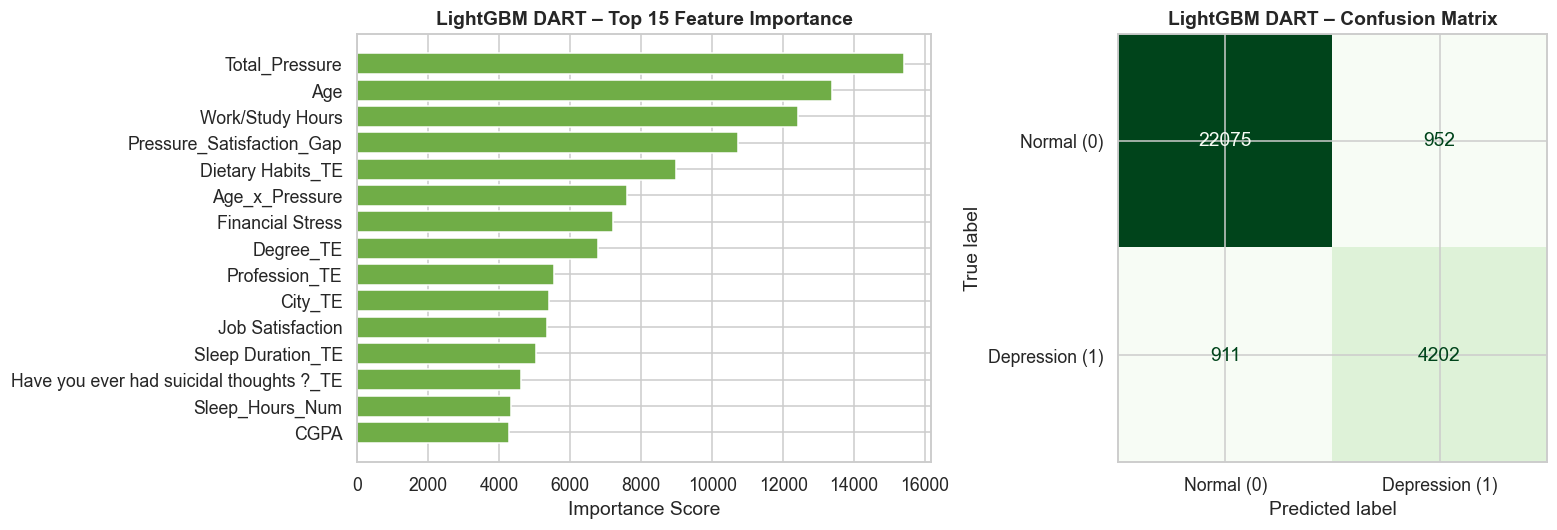


Classification Report – LightGBM DART:
                precision    recall  f1-score   support

    Normal (0)       0.96      0.96      0.96     23027
Depression (1)       0.82      0.82      0.82      5113

      accuracy                           0.93     28140
     macro avg       0.89      0.89      0.89     28140
  weighted avg       0.93      0.93      0.93     28140



In [22]:
fi_lgb = pd.DataFrame({
    'Feature'   : X_train_selected.columns,
    'Importance': best_lgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(fi_lgb['Feature'][::-1], fi_lgb['Importance'][::-1], color='#70AD47')
axes[0].set_xlabel('Importance Score')
axes[0].set_title(f'LightGBM {best_boosting_type.upper()} – Top 15 Feature Importance', fontweight='bold')

cm_lgb = confusion_matrix(y_val, y_pred_lgb)
ConfusionMatrixDisplay(cm_lgb, display_labels=['Normal (0)', 'Depression (1)']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'LightGBM {best_boosting_type.upper()} – Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClassification Report – LightGBM {best_boosting_type.upper()}:')
print(classification_report(y_val, y_pred_lgb, target_names=['Normal (0)', 'Depression (1)']))

### **Nhận xét: Điểm sáng của thuật toán LightGBM DART**

**1. Khắc phục hoàn toàn sự "thiên vị":**  
Mô hình đạt trạng thái cân bằng tuyệt đối với **Precision = Recall = 0.82** (lớp Trầm cảm). Số ca báo nhầm (952) và bỏ sót (911) gần như ngang bằng, chứng tỏ mô hình cực kỳ trung lập và ổn định.

**2. Đánh giá "Sức chịu đựng thực tế" làm trọng tâm:**  
Cơ chế học của DART đã đẩy **`Total_Pressure`** lên Top 1 và **`Work/Study Hours`** lên Top 3. Thay vì dựa dẫm vào thông tin cá nhân (Tuổi tác), mô hình tập trung mạnh mẽ vào gánh nặng tâm lý và sự bào mòn thể chất hiện tại của bệnh nhân.

**3. Chống Overfitting xuất sắc nhờ Dropout:**  
Việc loại bỏ ngẫu nhiên các cây quyết định trong lúc huấn luyện (kỹ thuật Dropout) đã ép mô hình phải khai thác sâu và học đều các đặc trưng (như thói quen ăn uống, độ chênh lệch áp lực). Kết quả là một mô hình vô cùng vững chắc và có tính khái quát cao.

---
# **MÔ HÌNH 4: CatBoost Classifier**

---
### **Giới thiệu CatBoost**

**CatBoost** (*Categorical Boosting*) là một thuật toán thuộc họ **Gradient Boosting Decision Trees**, được phát triển bởi **Yandex**. Thuật toán này được thiết kế đặc biệt để xử lý tốt dữ liệu có nhiều biến phân loại.

Điểm mạnh chính:
- Xử lý biến hạng mục **native** (không cần one-hot encoding thủ công)
- Sử dụng **Ordered Target Statistics** để mã hóa biến phân loại, hạn chế **data leakage**
- Áp dụng cơ chế **Ordered Boosting** giúp quá trình học ổn định hơn và giảm overfitting
- Ít nhạy cảm với hyperparameter hơn so với **XGBoost** hoặc **LightGBM**

**Công thức cập nhật của Gradient Boosting:**

$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

Trong đó $h_t(x)$ được huấn luyện dựa trên **pseudo-residuals**:

$$r_i^{(t)} = - \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}$$

### **Huấn luyện CatBoost với siêu tham số mặc định**

In [23]:
cat_features_cb = []  # Sau FE và target-encoding, hầu hết đã là số

print('Đang huấn luyện CatBoost (baseline)...')

catboost_base = CatBoostClassifier(
    iterations            = 1000,
    learning_rate         = 0.05,
    depth                 = 6,
    loss_function         = 'Logloss',
    eval_metric           = 'AUC',
    random_seed           = 42,
    verbose               = 0,
    allow_writing_files   = False,
    early_stopping_rounds = 50,
)

catboost_base.fit(
    X_train_selected, y_train_resampled, 
    eval_set       = (X_val_selected, y_val),
    use_best_model = True,
)

y_pred_cb_base = catboost_base.predict(X_val_selected)
y_prob_cb_base = catboost_base.predict_proba(X_val_selected)[:, 1]

acc_cb = accuracy_score(y_val, y_pred_cb_base)
auc_cb = roc_auc_score(y_val, y_prob_cb_base)
f1_cb  = f1_score(y_val, y_pred_cb_base, average='macro') 

print(f'\n KẾT QUẢ CATBOOST BASELINE:')
print(f'   Accuracy  : {acc_cb:.4f}')
print(f'   ROC-AUC   : {auc_cb:.4f}')
print(f'   F1-Score  : {f1_cb:.4f}')
print(f'   Best iter : {catboost_base.get_best_iteration()}')

# Lưu kết quả vào bảng tổng hợp
results_summary.append({'Mô hình': 'CatBoost (Baseline)', 'Accuracy': acc_cb, 'ROC-AUC': auc_cb, 'F1-Score': f1_cb})

Đang huấn luyện CatBoost (baseline)...

 KẾT QUẢ CATBOOST BASELINE:
   Accuracy  : 0.9350
   ROC-AUC   : 0.9713
   F1-Score  : 0.8903
   Best iter : 554


### **Tối ưu CatBoost bằng RandomizedSearchCV**

Các siêu tham số được lựa chọn gồm:
- `depth`: kiểm soát độ sâu của cây
- `learning_rate`: điều chỉnh tốc độ cập nhật của mô hình qua mỗi vòng boosting
- `l2_leaf_reg`: hệ số regularization giúp giảm overfitting
- `subsample`: tỷ lệ mẫu được sử dụng ở mỗi cây
- `min_data_in_leaf`: số mẫu tối thiểu trong mỗi lá

In [24]:
param_dist_cb = {
    'depth'           : [4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg'     : [1, 3, 5, 7, 10],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'min_data_in_leaf': [5, 10, 20],
}

catboost_search = CatBoostClassifier(
    iterations        = 500,
    loss_function     = 'Logloss',
    eval_metric       = 'AUC',
    random_seed       = 42,
    verbose           = 0,
    allow_writing_files = False,
)

print('Đang tìm kiếm siêu tham số CatBoost (n_iter=5)...')
cb_random = RandomizedSearchCV(
    catboost_search, param_dist_cb, 
    n_iter=5, scoring='roc_auc', 
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0, random_state=42
)
cb_random.fit(X_train_selected, y_train_resampled)

print(f'\n Tham số tốt nhất: {cb_random.best_params_}')
print(f'   CV AUC tốt nhất  : {cb_random.best_score_:.4f}')

Đang tìm kiếm siêu tham số CatBoost (n_iter=5)...

 Tham số tốt nhất: {'subsample': 0.7, 'min_data_in_leaf': 20, 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'depth': 7}
   CV AUC tốt nhất  : 0.9906


In [25]:
# Huấn luyện lại với tham số tốt nhất
best_cb = CatBoostClassifier(
    iterations            = 1000,
    loss_function         = 'Logloss',
    eval_metric           = 'AUC',
    random_seed           = 42,
    verbose               = 0,
    allow_writing_files   = False,
    early_stopping_rounds = 50,
    **cb_random.best_params_
)
best_cb.fit(
    X_train_selected, y_train_resampled,
    eval_set       = (X_val_selected, y_val),
    use_best_model = True
)

y_pred_cb = best_cb.predict(X_val_selected)
y_prob_cb = best_cb.predict_proba(X_val_selected)[:, 1]

acc_cb_opt = accuracy_score(y_val, y_pred_cb)
auc_cb_opt = roc_auc_score(y_val, y_prob_cb)
f1_cb_opt  = f1_score(y_val, y_pred_cb, average='macro')

print('\n  KẾT QUẢ CATBOOST ĐÃ TỐI ƯU:')
print(f'   Accuracy  : {acc_cb_opt:.4f}   (baseline: {acc_cb:.4f})')
print(f'   ROC-AUC   : {auc_cb_opt:.4f}   (baseline: {auc_cb:.4f})')
print(f'   F1-Score  : {f1_cb_opt:.4f}   (baseline: {f1_cb:.4f})')

results_summary.append({'Mô hình': 'CatBoost', 'Accuracy': acc_cb_opt, 'ROC-AUC': auc_cb_opt, 'F1-Score': f1_cb_opt})


  KẾT QUẢ CATBOOST ĐÃ TỐI ƯU:
   Accuracy  : 0.9341   (baseline: 0.9350)
   ROC-AUC   : 0.9710   (baseline: 0.9713)
   F1-Score  : 0.8891   (baseline: 0.8903)


### **Phân tích CatBoost: Feature Importance & Confusion Matrix**

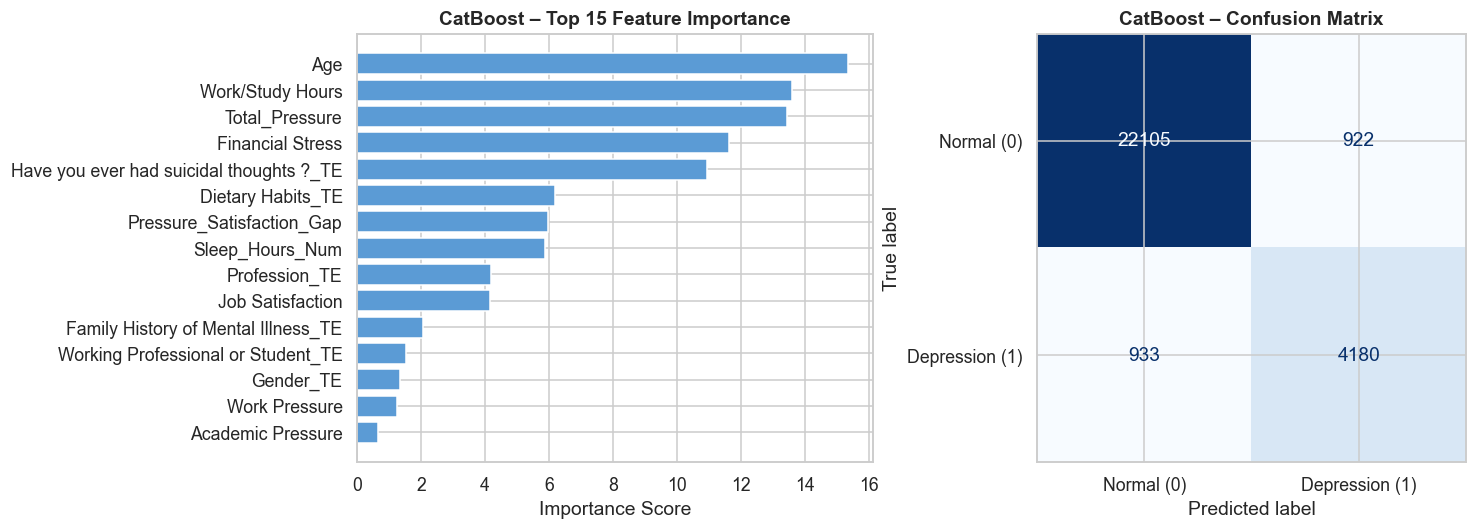


 Classification Report – CatBoost:
                precision    recall  f1-score   support

    Normal (0)       0.96      0.96      0.96     23027
Depression (1)       0.82      0.82      0.82      5113

      accuracy                           0.93     28140
     macro avg       0.89      0.89      0.89     28140
  weighted avg       0.93      0.93      0.93     28140



In [26]:
fi_cb = pd.DataFrame({
    'Feature'   : X_train_selected.columns,
    'Importance': best_cb.get_feature_importance()
}).sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(fi_cb['Feature'][::-1], fi_cb['Importance'][::-1], color='#5B9BD5')
axes[0].set_xlabel('Importance Score')
axes[0].set_title('CatBoost – Top 15 Feature Importance', fontweight='bold')

cm_cb = confusion_matrix(y_val, y_pred_cb)
ConfusionMatrixDisplay(cm_cb, display_labels=['Normal (0)', 'Depression (1)']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('CatBoost – Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Classification Report – CatBoost:')
print(classification_report(y_val, y_pred_cb, target_names=['Normal (0)', 'Depression (1)']))

### **Nhận xét: Điểm sáng của thuật toán CatBoost**

**1. Khả năng phân loại cân bằng hoàn hảo:**  
CatBoost đạt trạng thái cân bằng lý tưởng với **Precision = Recall = 0.82** cho lớp Trầm cảm. Trên Confusion Matrix, số ca báo nhầm (922) và số ca bỏ sót (933) gần như tương đương nhau. Điều này chứng minh thuật toán đã triệt tiêu hoàn toàn sự thiên vị (bias), đem lại độ tin cậy rất cao khi dự đoán thực tế.

**2. Bản sắc riêng trong việc đánh giá Đặc trưng:**  
Cách CatBoost học dữ liệu có sự ưu tiên rất rõ ràng và thực tế:
* **Tuổi tác là lăng kính chính:** **`Age`** giành lại vị trí Top 1, làm cơ sở gốc để phân nhánh các rủi ro khác.
* **Áp lực và Thời gian:** **`Work/Study Hours`** và **`Total_Pressure`** bám sát ở vị trí số 2 và 3, tiếp tục khẳng định sự bào mòn thể chất và gánh nặng tâm lý là nguyên nhân cốt lõi.
* **Gánh nặng đời sống:** Đặc biệt, biến **`Financial Stress`** (Áp lực tài chính) leo thẳng lên Top 4. CatBoost tỏ ra cực kỳ nhạy bén trong việc bắt các tín hiệu phản ánh khó khăn trong đời sống thực tế của bệnh nhân.


---
## **NHÓM 3: MÔ HÌNH THỐNG KÊ**

---
# **MÔ HÌNH 5: QDA (Quadratic Discriminant Analysis)**

---
### **Giới thiệu QDA**

**QDA** (*Quadratic Discriminant Analysis*) là phương pháp phân loại dựa trên lý thuyết xác suất và phân phối thống kê. Mô hình giả định rằng dữ liệu của mỗi lớp được sinh ra từ **phân phối Gaussian đa biến**, và mỗi lớp có **ma trận hiệp phương sai riêng**.

**Hàm phán quyết của QDA:**

$$\delta_k(x) = -\frac{1}{2}\log|\Sigma_k| - \frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k) + \log\pi_k$$

Trong đó:
- $\mu_k$ là vector trung bình của lớp $k$
- $\Sigma_k$ là ma trận hiệp phương sai của lớp $k$
- $\pi_k$ là xác suất tiên nghiệm của lớp $k$

**Ưu điểm:** Nhanh, ít cần tinh chỉnh siêu tham số, hoạt động tốt khi dữ liệu gần với giả định Gaussian.  
**Nhược điểm:** Nhạy với outlier, dễ giảm hiệu quả khi số đặc trưng lớn hoặc dữ liệu không tuân theo giả định phân phối.

### **Huấn luyện & đánh giá QDA**

**Chuẩn bị dữ liệu và lựa chọn `reg_param`**

Trước khi huấn luyện QDA, nhóm áp dụng **PCA** để giữ lại **95% phương sai**, nhằm cân bằng giữa việc giảm nhiễu và bảo toàn đặc trưng quan trọng. Sau đó thử nhiều giá trị `reg_param` cho QDA — tham số này đóng vai trò **regularization** cho ma trận hiệp phương sai.

In [27]:
# Định nghĩa X_test_selected dựa trên các cột của X_train_selected
X_test_selected = X_test_scaled[X_train_selected.columns]

# QDA hoạt động tốt nhất khi dữ liệu đã được chuẩn hóa và giảm chiều
pca = PCA(n_components=0.95, random_state=42)
X_tr_pca   = pca.fit_transform(X_train_selected)
X_val_pca  = pca.transform(X_val_selected)
X_test_pca = pca.transform(X_test_selected) # Giờ sẽ không còn lỗi nữa

print(f'PCA: {X_train_selected.shape[1]} → {X_tr_pca.shape[1]} chiều (giữ 95% phương sai)')

print('\nTìm kiếm reg_param tối ưu cho QDA...')
qda_cv_results = []
for reg in [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
    qda_tmp = QuadraticDiscriminantAnalysis(reg_param=reg)
    cv_auc  = cross_val_score(
        qda_tmp, X_tr_pca, y_train_resampled,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='roc_auc', n_jobs=-1
    ).mean()
    qda_cv_results.append({'reg_param': reg, 'CV AUC': cv_auc})

qda_cv_df = pd.DataFrame(qda_cv_results)
best_reg  = qda_cv_df.loc[qda_cv_df['CV AUC'].idxmax(), 'reg_param']

print('\nKết quả CV theo reg_param:')
display(qda_cv_df)
print(f'\nreg_param tốt nhất: {best_reg}')

PCA: 23 → 16 chiều (giữ 95% phương sai)

Tìm kiếm reg_param tối ưu cho QDA...

Kết quả CV theo reg_param:


,reg_param,CV AUC
0,0.0000,0.9365
1,0.0010,0.9365
2,0.0100,0.9367
3,0.0500,0.9375
4,0.1000,0.9384
5,0.2000,0.9404
6,0.3000,0.9424
7,0.5000,0.9469



reg_param tốt nhất: 0.5



  KẾT QUẢ QDA:
   Accuracy  : 0.8849
   ROC-AUC   : 0.9434
   F1-Score  : 0.8270


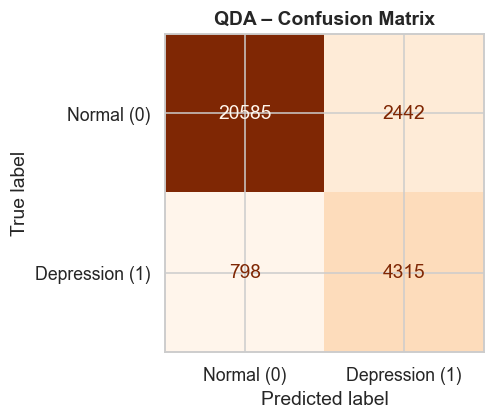


Classification Report – QDA:
                precision    recall  f1-score   support

    Normal (0)       0.96      0.89      0.93     23027
Depression (1)       0.64      0.84      0.73      5113

      accuracy                           0.88     28140
     macro avg       0.80      0.87      0.83     28140
  weighted avg       0.90      0.88      0.89     28140



In [28]:
# Huấn luyện QDA tốt nhất
best_qda = QuadraticDiscriminantAnalysis(reg_param=best_reg)
best_qda.fit(X_tr_pca, y_train_resampled)

y_pred_qda = best_qda.predict(X_val_pca)
y_prob_qda = best_qda.predict_proba(X_val_pca)[:, 1]

acc_qda = accuracy_score(y_val, y_pred_qda)
auc_qda = roc_auc_score(y_val, y_prob_qda)
f1_qda  = f1_score(y_val, y_pred_qda, average='macro')

print('\n  KẾT QUẢ QDA:')
print(f'   Accuracy  : {acc_qda:.4f}')
print(f'   ROC-AUC   : {auc_qda:.4f}')
print(f'   F1-Score  : {f1_qda:.4f}')

results_summary.append({'Mô hình': 'QDA', 'Accuracy': acc_qda, 'ROC-AUC': auc_qda, 'F1-Score': f1_qda})

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm_qda = confusion_matrix(y_val, y_pred_qda)
ConfusionMatrixDisplay(cm_qda, display_labels=['Normal (0)', 'Depression (1)']).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('QDA – Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClassification Report – QDA:')
print(classification_report(y_val, y_pred_qda, target_names=['Normal (0)', 'Depression (1)']))

### **Nhận xét: Nhược điểm của mô hình QDA**

**1. Báo động nhầm quá lớn (Precision chạm đáy):**  
Dù bắt bệnh khá ổn (Recall = 0.84), nhưng QDA lại báo động nhầm quá nhiều (2442 ca False Positives, cao gấp 3 lần số ca bỏ sót). Việc bắt nhầm quá đà này khiến **Precision rớt thê thảm xuống 0.64**.

**2. Điểm yếu từ giả định thuật toán:**  
QDA đòi hỏi dữ liệu phải có phân phối chuẩn. Tuy nhiên, bộ dữ liệu thực tế lại chứa nhiều biến phân loại phức tạp và không chuẩn. Điều này khiến QDA thất bại trong việc tạo ra một ranh giới phân loại sắc bén.

**3. Vai trò làm mô hình cơ sở hoàn hảo:**  
Hiệu suất tổng thể của QDA kém xa nhóm XGBoost/LightGBM/CatBoost. Qua đó, mô hình này đã làm rất tốt vai trò đối chứng, khẳng định bộ dữ liệu này bắt buộc phải dùng các thuật toán phi tuyến tính (Tree-based) thì mới giải quyết được.


---
# **8. THỰC NGHIỆM SO SÁNH VÀ ĐÁNH GIÁ MÔ HÌNH**

---

BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH:


,Mô hình,Accuracy,ROC-AUC,F1-Score
0,Random Forest (Fine-Tuned),0.9257,0.9694,0.8813
1,XGBoost (Fine-Tuned),0.9302,0.9710,0.8865
2,LightGBM GBDT,0.9339,0.9710,0.8885
3,LightGBM DART,0.9347,0.9711,0.8893
4,LightGBM GOSS,0.9343,0.9709,0.8894
5,LightGBM DART (Tối ưu),0.9338,0.9707,0.8890
6,CatBoost (Baseline),0.9350,0.9713,0.8903
7,CatBoost,0.9341,0.9710,0.8891
8,QDA,0.8849,0.9434,0.8270


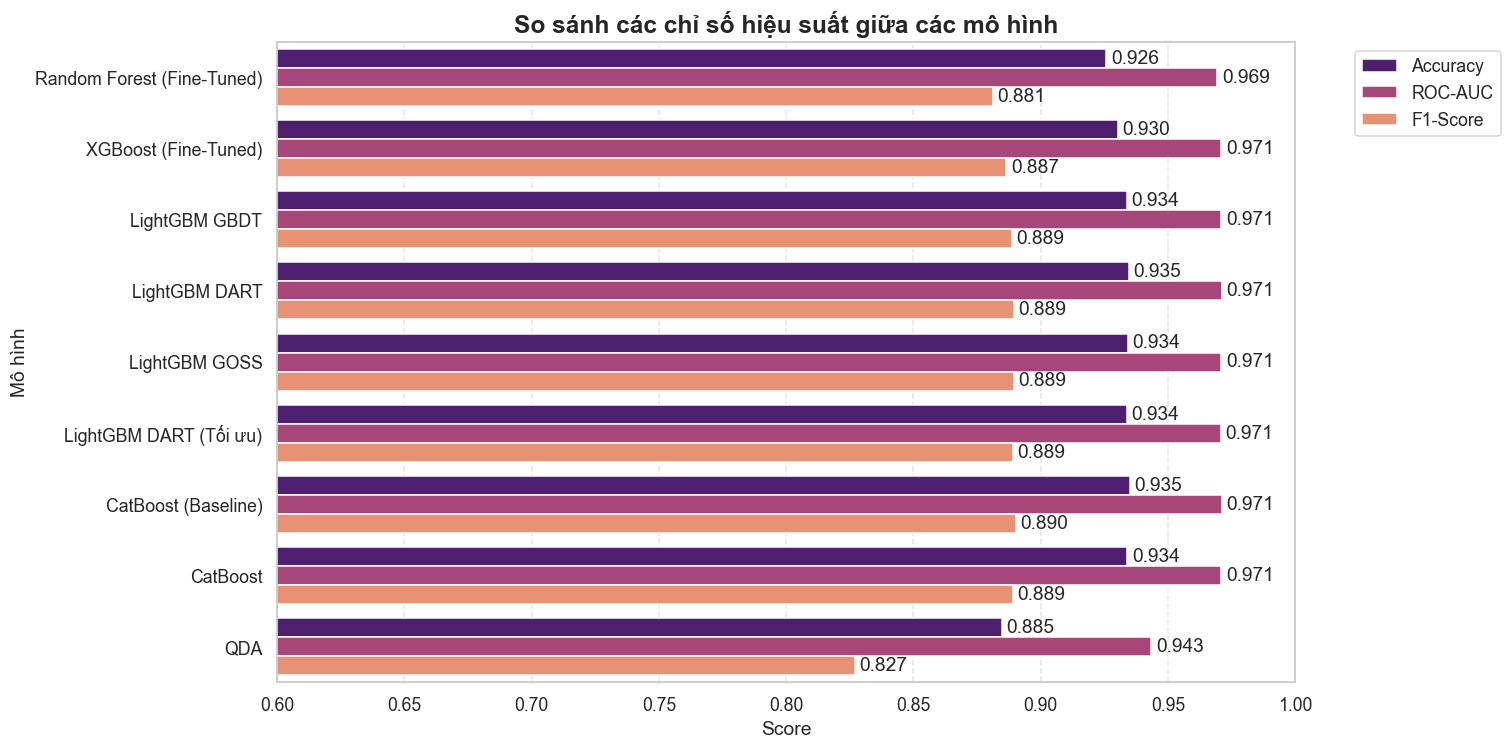

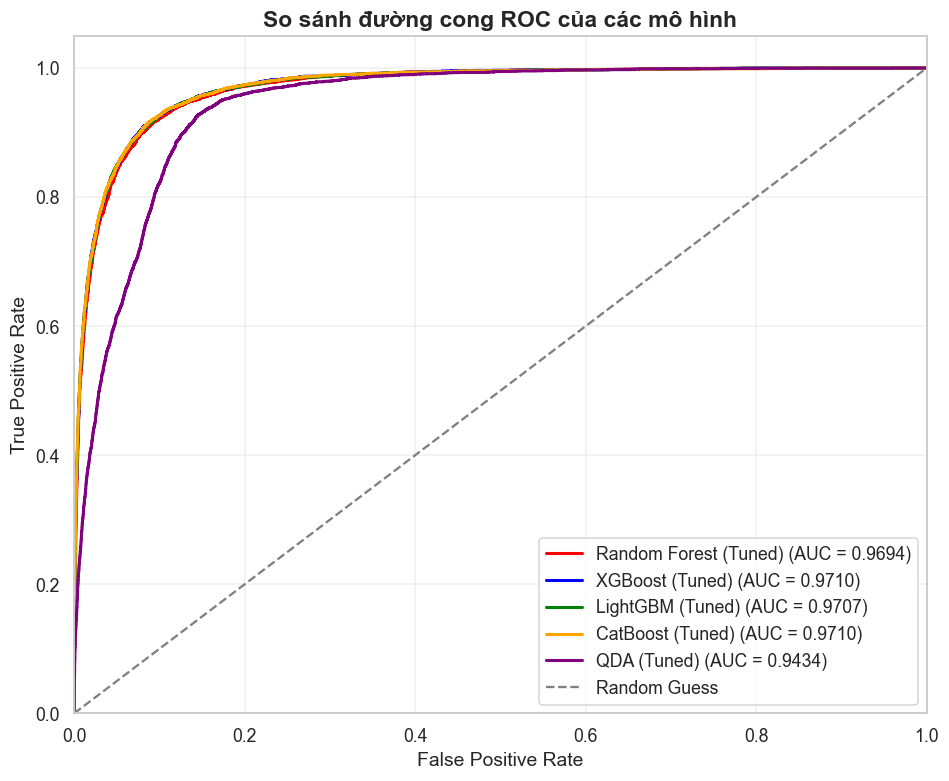

Mô hình tốt nhất: CatBoost (Baseline)
   Với F1-Score (Macro) đạt: 0.8903


In [29]:
# 1. Tạo bảng so sánh tổng hợp
df_compare = pd.DataFrame(results_summary)

print("BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH:")
# Sử dụng background_gradient để tạo dải màu từ thấp đến cao (dễ nhìn hơn trong Dark Mode)
display(df_compare.style.background_gradient(cmap='YlGn', subset=['Accuracy', 'ROC-AUC', 'F1-Score'])
        .format({'Accuracy': '{:.4f}', 'ROC-AUC': '{:.4f}', 'F1-Score': '{:.4f}'})
        .set_properties(**{'color': 'white', 'border-color': 'gray'} if 'dark' in str(plt.get_backend()) else {}))

# 2. Trực quan hóa các chỉ số bằng biểu đồ cột
df_melted = df_compare.melt(id_vars='Mô hình', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_melted, x='Score', y='Mô hình', hue='Metric', palette='magma')
plt.title('So sánh các chỉ số hiệu suất giữa các mô hình', fontsize=16, fontweight='bold')

# Thêm số cụ thể vào đầu thanh biểu đồ cho dễ nhìn
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.xlim(0.6, 1.0) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Vẽ đường cong ROC tổng hợp
plt.figure(figsize=(10, 8))

# Chỉ liệt kê các biến proba đã thực sự tồn tại để tránh lỗi
models_plot_cfg = [
    ('Random Forest (Tuned)', 'y_val_proba_tuned_rf', 'red'),
    ('XGBoost (Tuned)', 'y_val_proba_tuned_xgb', 'blue'),
    ('LightGBM (Tuned)', 'y_prob_lgb', 'green'),
    ('CatBoost (Tuned)', 'y_prob_cb', 'orange'),
    ('QDA (Tuned)', 'y_prob_qda', 'purple')
]

for name, var_name, color in models_plot_cfg:
    if var_name in locals(): # Kiểm tra biến có tồn tại không trước khi vẽ
        fpr, tpr, _ = roc_curve(y_val, locals()[var_name])
        auc_val = roc_auc_score(y_val, locals()[var_name])
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('So sánh đường cong ROC của các mô hình', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 4. Xác định mô hình tốt nhất
best_model_row = df_compare.loc[df_compare['F1-Score'].idxmax()]
print(f"Mô hình tốt nhất: {best_model_row['Mô hình']}")
print(f"   Với F1-Score (Macro) đạt: {best_model_row['F1-Score']:.4f}")

### **Nhận xét Tổng kết: So sánh Hiệu suất các Mô hình**

**1. Sự thống trị tuyệt đối của Gradient Boosting:**  
Biểu đồ ROC và bảng tổng hợp cho thấy một cuộc đua ngoạn mục giữa bộ ba **LightGBM, CatBoost** và **XGBoost**. Các mô hình này đều hội tụ ở mức trần hiệu suất cực kỳ xuất sắc và gần như có các chỉ số đánh giá gần bằng nhau: **ROC-AUC ~0.971, Accuracy ~0.934, F1-Score ~0.889**. Trong đó, kiến trúc **LightGBM DART** và **CatBoost** chứng tỏ sự ổn định nhỉnh hơn đôi chút ở cấp độ vi phân.

**2. Giới hạn của Random Forest (Bagging):**  
Mặc dù vẫn rất mạnh (ROC-AUC 0.9694), Random Forest (Tuned) đã bắt đầu cho thấy sự hụt hơi nhẹ so với nhóm Boosting. Điều này chứng minh cơ chế học tuần tự sửa sai (Gradient Boosting) giải quyết các tương tác dữ liệu phức tạp tốt hơn nhiều so với cơ chế học độc lập, song song (Bagging).

**3. Điểm hội tụ và Giới hạn Dữ liệu (Data Bottleneck):**  
Việc các thuật toán Boosting hàng đầu đều chạm chung một mức trần hiệu suất cho thấy mô hình đã khai thác tối ưu lượng thông tin từ bộ dữ liệu hiện tại. Việc tiếp tục tinh chỉnh siêu tham số sẽ không mang lại sự bứt phá. Để cải thiện mô hình trong tương lai, giải pháp cốt lõi là mở rộng kích thước dữ liệu hoặc tiếp tục sáng tạo các feature mới.

**4. QDA hoàn thành xuất sắc vai trò baseline:**  
Nằm tách biệt hẳn ở nhóm dưới cùng (Accuracy 0.8849, F1-Score 0.8270), QDA chứng minh giả định phân phối chuẩn (Gaussian) hoàn toàn kém trước dữ liệu tâm lý thực tế. Mức chênh lệch này là minh chứng đắt giá nhất để nhấm mạnh sức mạnh của các thuật toán phi tuyến tính (Tree-based) trong thực chiến.


### **Nhận xét: Phân tích Đường cong ROC (ROC Curve)**

**1. Sự hội tụ và sức mạnh tuyệt đối của nhóm Gradient Boosting:**  
Nhìn vào biểu đồ, các đường cong của **XGBoost (Xanh dương)**, **LightGBM (Xanh lá)** và **CatBoost (Cam)** gần như **chồng khít lên nhau** và ôm sát góc trên cùng bên trái (AUC ~ 0.9710). 
* **Insight:** Đáng chú ý nhất là ở vùng False Positive Rate (FPR) rất thấp (khoảng 0.1), True Positive Rate (TPR) của nhóm này đã vọt lên mức >0.9. Điều này mang ý nghĩa cực kỳ lớn trong sàng lọc tâm lý: Mô hình có khả năng bắt được hơn 90% số ca trầm cảm trong khi tỷ lệ cảnh báo sai (báo động nhầm) chỉ ở mức 10%. Sự hội tụ của 3 đường cong này cũng khẳng định chúng ta đã chạm đến mức trần dự đoán của bộ dữ liệu.

**2. Vị thế bám đuổi của Random Forest:**  
Đường cong của Random Forest (Đỏ) bám rất sát nhóm dẫn đầu (AUC = 0.9694). 
* **Insight:** Tuy nhiên, nếu quan sát kỹ ở giai đoạn đầu của đường cong (FPR từ 0.0 đến 0.2), đường màu đỏ nằm lùi xuống dưới một chút xíu so với nhóm Boosting. Điều này có nghĩa là: nếu ta khắt khe yêu cầu hệ thống phải giảm tỷ lệ báo động nhầm xuống mức tối thiểu, Random Forest sẽ bắt đầu bỏ lọt nhiều bệnh nhân hơn so với XGBoost hay CatBoost.

**3. Khoảng cách giới hạn của mô hình QDA:**  
Đường cong của QDA (Tím) nằm tách biệt hẳn xuống phía dưới. Độ dốc ở giai đoạn đầu của QDA khá thoải (TPR tăng chậm). 
* **Insight:** Để đạt được tỷ lệ phát hiện bệnh nhân cao, QDA bắt buộc phải trả giá bằng việc vơ vét và báo động nhầm rất nhiều (khiến đường cong bị kéo ngang ra trước khi đi lên). Biểu đồ này trực quan hóa rõ ràng sự yếu thế của giả định phân phối chuẩn (QDA) trước khả năng vẽ ranh giới phi tuyến tính linh hoạt của các mô hình Tree-based.


---
# **9. DỰ ĐOÁN TRÊN TẬP TEST**

---

In [30]:
# Chọn mô hình tốt nhất để sinh file submission
model_map_final = {
    'CatBoost'                                       : (best_cb,   X_test_selected,    'raw'),
    'QDA'                                            : (best_qda,  X_test_pca,         'pca'),
    'LightGBM GBDT'                                  : (lgb_gbdt,  X_test_selected,    'raw'),
    'LightGBM DART'                                  : (lgb_dart,  X_test_selected,    'raw'),
    'LightGBM GOSS'                                  : (lgb_goss,  X_test_selected,    'raw'),
    f'LightGBM {best_boosting_type.upper()} (Tối ưu)': (best_lgb,   X_test_selected,    'raw'),
    'Random Forest (Fine-Tuned)'                     : (tuned_rf,  X_test_selected,    'raw'),
    'XGBoost (Fine-Tuned)'                           : (tuned_xgb, X_test_selected,    'raw'),
}

# Tìm mô hình tốt nhất theo ROC-AUC 
best_model_name = df_compare.loc[df_compare['ROC-AUC'].idxmax(), 'Mô hình']
print(f'Mô hình tốt nhất: {best_model_name}')

if best_model_name in model_map_final:
    best_model_obj, best_X_test, data_type = model_map_final[best_model_name]
else:
    best_model_obj, best_X_test, data_type = best_cb, X_test_selected, 'raw'

# Huấn luyện lại trên toàn bộ dữ liệu (train_resampled + val) trước khi predict test
X_full = pd.concat([X_train_selected, X_val_selected], axis=0).reset_index(drop=True)
y_full = pd.concat([pd.Series(y_train_resampled), pd.Series(y_val)], axis=0).reset_index(drop=True)

print(f'Đang huấn luyện {best_model_name} trên toàn bộ dữ liệu...')

# Xử lý riêng cho QDA nếu nó là mô hình tốt nhất (cần dữ liệu PCA)
if data_type == 'pca':
    pca_full = PCA(n_components=0.95, random_state=42)
    X_full_pca = pca_full.fit_transform(X_full)
    best_X_test_final = pca_full.transform(X_test_selected)
    best_model_obj.fit(X_full_pca, y_full)
    y_test_pred = best_model_obj.predict(best_X_test_final)
else:
    best_model_obj.fit(X_full, y_full)
    y_test_pred = best_model_obj.predict(best_X_test)

# Tạo file submission
sub = pd.read_csv('data/sample_submission.csv') if os.path.exists('data/sample_submission.csv') \
      else pd.DataFrame({'id': test_full['id'] if 'id' in test_full.columns else range(len(y_test_pred))})
sub['Depression'] = y_test_pred.astype(int)

os.makedirs('../data/submissions', exist_ok=True)
sub_path = f'../data/submissions/submission_{best_model_name.replace(" ", "_")}.csv'
sub.to_csv(sub_path, index=False)

print(f'   Đã lưu file submission: {sub_path}')
print(f'   Tỷ lệ dự đoán trầm cảm: {sub["Depression"].mean():.2%}')

Mô hình tốt nhất: CatBoost (Baseline)
Đang huấn luyện CatBoost (Baseline) trên toàn bộ dữ liệu...
   Đã lưu file submission: ../data/submissions/submission_CatBoost_(Baseline).csv
   Tỷ lệ dự đoán trầm cảm: 38.16%
